In [2]:
import os
import pandas as pd
from collections import defaultdict

In [3]:
def merge_files_from_two_folders(folder1, folder2):
    file_groups = defaultdict(list)

    # 두 폴더에서 파일 이름 기준으로 파일 경로 수집
    for folder in [folder1, folder2]:
        for file in os.listdir(folder):
            if file.endswith(".csv"):
                file_path = os.path.join(folder, file)
                file_groups[file].append(file_path)

    merged_data = {}

    for file_name, file_list in file_groups.items():
        if len(file_list) < 2:
            print(f"⚠️ 병합 불가 (두 폴더 모두에 존재하지 않음): {file_name}")
            continue

        print(f"\n📎 병합 중: {file_name}")

        # 두 파일 읽기
        df1 = pd.read_csv(file_list[0])
        df2 = pd.read_csv(file_list[1])

        # 컬럼 존재 확인 및 정제
        if "ObjectName" in df2.columns:
            df2 = df2.rename(columns={"ObjectName": "object_name"})
        if "ObjectName" in df1.columns:
            df1 = df1.rename(columns={"ObjectName": "object_name"})

        if "session" not in df1.columns or "session" not in df2.columns:
            print(f"❌ session 컬럼이 누락된 파일: {file_name}")
            continue

        # session 형 변환
        df1["session"] = df1["session"].astype(int)
        df2["session"] = df2["session"].astype(int)

        # 병합 (object_name + session 기준)
        merged_df = pd.merge(df1, df2, on=["object_name", "session"], how="inner")

        # 저장
        merged_data[file_name] = merged_df

    return merged_data

In [4]:
folder1 = ".\Full\CountGrab_Full\Full_data"
folder2 = ".\Full\Sequence_Full\Full_data"

merged = merge_files_from_two_folders(folder1, folder2)

print(merged.keys())


📎 병합 중: bosung_full.csv

📎 병합 중: dohoon_full.csv

📎 병합 중: euncha_full.csv

📎 병합 중: hyunwook_full.csv

📎 병합 중: jaeho_full.csv

📎 병합 중: jaehu_full.csv

📎 병합 중: jinu_full.csv

📎 병합 중: jiyoung_full.csv

📎 병합 중: minho_full.csv

📎 병합 중: minju_full.csv

📎 병합 중: sarang_full.csv

📎 병합 중: seongjun_full.csv

📎 병합 중: siu_full.csv

📎 병합 중: suhan_full.csv

📎 병합 중: suyeoun_full.csv

📎 병합 중: taeyoon_full.csv

📎 병합 중: uiseong_full.csv

📎 병합 중: wonbin_full.csv

📎 병합 중: youngtaek_full.csv

📎 병합 중: ys_full.csv
dict_keys(['bosung_full.csv', 'dohoon_full.csv', 'euncha_full.csv', 'hyunwook_full.csv', 'jaeho_full.csv', 'jaehu_full.csv', 'jinu_full.csv', 'jiyoung_full.csv', 'minho_full.csv', 'minju_full.csv', 'sarang_full.csv', 'seongjun_full.csv', 'siu_full.csv', 'suhan_full.csv', 'suyeoun_full.csv', 'taeyoon_full.csv', 'uiseong_full.csv', 'wonbin_full.csv', 'youngtaek_full.csv', 'ys_full.csv'])


In [5]:
output_dir = ".\Full"

In [6]:
merged_list = list(merged.values())
merged_list_index = list(merged.keys())


for i in range(len(merged_list_index)):
    export_path = os.path.join(output_dir, f"Merge_{merged_list_index[i]}")
    merged_list[i].to_csv(export_path, index=False, encoding='utf-8-sig')  # utf-8-sig로 한글 깨짐 방지
    print(f"💾 저장 완료: {export_path}")

💾 저장 완료: .\Full\Merge_bosung_full.csv
💾 저장 완료: .\Full\Merge_dohoon_full.csv
💾 저장 완료: .\Full\Merge_euncha_full.csv
💾 저장 완료: .\Full\Merge_hyunwook_full.csv
💾 저장 완료: .\Full\Merge_jaeho_full.csv
💾 저장 완료: .\Full\Merge_jaehu_full.csv
💾 저장 완료: .\Full\Merge_jinu_full.csv
💾 저장 완료: .\Full\Merge_jiyoung_full.csv
💾 저장 완료: .\Full\Merge_minho_full.csv
💾 저장 완료: .\Full\Merge_minju_full.csv
💾 저장 완료: .\Full\Merge_sarang_full.csv
💾 저장 완료: .\Full\Merge_seongjun_full.csv
💾 저장 완료: .\Full\Merge_siu_full.csv
💾 저장 완료: .\Full\Merge_suhan_full.csv
💾 저장 완료: .\Full\Merge_suyeoun_full.csv
💾 저장 완료: .\Full\Merge_taeyoon_full.csv
💾 저장 완료: .\Full\Merge_uiseong_full.csv
💾 저장 완료: .\Full\Merge_wonbin_full.csv
💾 저장 완료: .\Full\Merge_youngtaek_full.csv
💾 저장 완료: .\Full\Merge_ys_full.csv


In [7]:
english_objects = {"Fur ball", "Sponge ball", "bouncy ball", "BaseBall", "Steal ball"}
number_zone_map = {"0": 0, "10": 1, "30": 2, "50": 3, "100": 4}
english_zone_map = {
    "Fur ball": 0,
    "Sponge ball": 1,
    "bouncy ball": 2,
    "BaseBall": 3,
    "Steal ball": 4
}

# 기대 zone 계산 함수
def get_expected_zone(obj):
    if obj in number_zone_map:
        return number_zone_map[obj]
    elif obj in english_zone_map:
        return english_zone_map[obj]
    else:
        return None

# 처리 함수
def process_and_save_files(folder_path, save_folder=None):
    os.makedirs(save_folder, exist_ok=True) if save_folder else None

    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)

            # 전처리
            df["object_name"] = df["object_name"].astype(str)
            df["expected_zone"] = df["object_name"].apply(get_expected_zone)
            df["correct"] = df["zone"] == df["expected_zone"]

            # 저장 경로 설정
            if save_folder:
                save_path = os.path.join(save_folder, file)
            else:
                save_path = file_path  # 원본 덮어쓰기

            df.to_csv(save_path, index=False, encoding="utf-8-sig")
            print(f"✅ 저장 완료: {save_path}")


process_and_save_files("./Full")                     # 원본에 덮어쓰기

✅ 저장 완료: ./Full\Merge_bosung_full.csv
✅ 저장 완료: ./Full\Merge_dohoon_full.csv
✅ 저장 완료: ./Full\Merge_euncha_full.csv
✅ 저장 완료: ./Full\Merge_hyunwook_full.csv
✅ 저장 완료: ./Full\Merge_jaeho_full.csv
✅ 저장 완료: ./Full\Merge_jaehu_full.csv
✅ 저장 완료: ./Full\Merge_jinu_full.csv
✅ 저장 완료: ./Full\Merge_jiyoung_full.csv
✅ 저장 완료: ./Full\Merge_minho_full.csv
✅ 저장 완료: ./Full\Merge_minju_full.csv
✅ 저장 완료: ./Full\Merge_sarang_full.csv
✅ 저장 완료: ./Full\Merge_seongjun_full.csv
✅ 저장 완료: ./Full\Merge_siu_full.csv
✅ 저장 완료: ./Full\Merge_suhan_full.csv
✅ 저장 완료: ./Full\Merge_suyeoun_full.csv
✅ 저장 완료: ./Full\Merge_taeyoon_full.csv
✅ 저장 완료: ./Full\Merge_uiseong_full.csv
✅ 저장 완료: ./Full\Merge_wonbin_full.csv
✅ 저장 완료: ./Full\Merge_youngtaek_full.csv
✅ 저장 완료: ./Full\Merge_ys_full.csv


In [8]:
no_experience = {"bosung", "jaehu", "minju", "sarang", "siu", "suyeoun", "wonbin", "jinu", "youngtaek", "suhan"}

# 전체 폴더 경로
folder_path = "./Full"

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        participant_name = file.replace("Merge_", "").replace("_full.csv", "")
        is_experienced = participant_name not in no_experience

        df = pd.read_csv(file_path)
        df["exp"] = is_experienced

        # 저장
        df.to_csv(file_path, index=False, encoding="utf-8-sig")
        print(f"✅ 실험 경험 컬럼 추가 완료: {file} → {'True' if is_experienced else 'False'}")

✅ 실험 경험 컬럼 추가 완료: Merge_bosung_full.csv → False
✅ 실험 경험 컬럼 추가 완료: Merge_dohoon_full.csv → True
✅ 실험 경험 컬럼 추가 완료: Merge_euncha_full.csv → True
✅ 실험 경험 컬럼 추가 완료: Merge_hyunwook_full.csv → True
✅ 실험 경험 컬럼 추가 완료: Merge_jaeho_full.csv → True
✅ 실험 경험 컬럼 추가 완료: Merge_jaehu_full.csv → False
✅ 실험 경험 컬럼 추가 완료: Merge_jinu_full.csv → False
✅ 실험 경험 컬럼 추가 완료: Merge_jiyoung_full.csv → True
✅ 실험 경험 컬럼 추가 완료: Merge_minho_full.csv → True
✅ 실험 경험 컬럼 추가 완료: Merge_minju_full.csv → False
✅ 실험 경험 컬럼 추가 완료: Merge_sarang_full.csv → False
✅ 실험 경험 컬럼 추가 완료: Merge_seongjun_full.csv → True
✅ 실험 경험 컬럼 추가 완료: Merge_siu_full.csv → False
✅ 실험 경험 컬럼 추가 완료: Merge_suhan_full.csv → False
✅ 실험 경험 컬럼 추가 완료: Merge_suyeoun_full.csv → False
✅ 실험 경험 컬럼 추가 완료: Merge_taeyoon_full.csv → True
✅ 실험 경험 컬럼 추가 완료: Merge_uiseong_full.csv → True
✅ 실험 경험 컬럼 추가 완료: Merge_wonbin_full.csv → False
✅ 실험 경험 컬럼 추가 완료: Merge_youngtaek_full.csv → False
✅ 실험 경험 컬럼 추가 완료: Merge_ys_full.csv → True


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

# 기준 오브젝트
english_objects = {"Fur ball", "Sponge ball", "bouncy ball", "BaseBall", "Steal ball"}
number_objects = {"0", "10", "30", "50", "100"}

# 세션 분류 함수
def classify_object_type(session_df):
    object_names = set(session_df["object_name"].astype(str))
    if object_names.issubset(english_objects):
        return "재질 O"
    elif object_names.issubset(number_objects):
        return "재질 X"
    else:
        return "혼합"

# 전체 누적 결과 저장용 리스트
all_sessions = []

def plot_total_grab(folder_path):
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)

            # 전처리
            df = df.dropna(subset=["session", "object_name", "total_grab", "correct"])
            df["object_name"] = df["object_name"].astype(str)
            df["session"] = df["session"].astype(int)
            df["total_grab"] = df["total_grab"].astype(float)
            df["correct"] = df["correct"].astype(bool)

            session_info = []
            for session_id, session_df in df.groupby("session"):
                obj_type = classify_object_type(session_df)
                last_total_grab = session_df["total_grab"].iloc[-1]
                accuracy = session_df["correct"].mean() * 100
                duration = session_df["session_duration"].iloc[-1]
                session_info.append({
                    "session": session_id,
                    "object_type": obj_type,
                    "total_grab": last_total_grab,
                    "accuracy": accuracy,
                    "session_duration": duration,
                    "source_file": file
                })

            result_df = pd.DataFrame(session_info)
            all_sessions.append(result_df)  # ✅ 누적

            # 파일별 출력
            eng_df = result_df[result_df["object_type"] == "재질 O"]
            num_df = result_df[result_df["object_type"] == "재질 X"]

            print(f"\n📄 파일: {file}")
            print(f"🧠 재질 O 평균 total_grab: {eng_df['total_grab'].mean():.2f}" if not eng_df.empty else "❌ 재질 O 세션 없음")
            print(f"🔢 재질 X 평균 total_grab: {num_df['total_grab'].mean():.2f}" if not num_df.empty else "❌ 재질 X 세션 없음")

            print("🎯 평균 정확도 (%):")
            print(f"   🧠 재질 O: {eng_df['accuracy'].mean():.2f}%" if not eng_df.empty else "   ❌ 재질 O 세션 없음")
            print(f"   🔢 재질 X: {num_df['accuracy'].mean():.2f}%" if not num_df.empty else "   ❌ 재질 X 세션 없음")

            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

            # print(eng_df.columns)
    
            # total_grab plot
            for df_type, label, color in zip([eng_df, num_df], ["재질 O", "재질 X"], ["blue", "green"]):
                if not df_type.empty:
                    ax1.plot(df_type["session"], df_type["total_grab"], marker='o', label=label, color=color)
            ax1.set_title(f"{file} - 세션별 Total Grab")
            ax1.set_ylabel("Total Grab")
            ax1.legend()
            ax1.grid(True)

            # session_duration plot
            for df_type, label, color in zip([eng_df, num_df], ["재질 O", "재질 X"], ["blue", "green"]):
                if not df_type.empty and "session_duration" in df_type.columns:
                    ax2.plot(df_type["session"], df_type["session_duration"], marker='s', linestyle='--', label=label, color=color)
            ax2.set_title("세션별 Duration (초)")
            ax2.set_xlabel("Session")
            ax2.set_ylabel("Duration (s)")
            ax2.legend()
            ax2.grid(True)

            plt.tight_layout()
            plt.show()


    # ✅ 전체 세션 결과 통합 후 계산
    full_df = pd.concat(all_sessions, ignore_index=True)

    eng_all = full_df[full_df["object_type"] == "재질 O"]
    num_all = full_df[full_df["object_type"] == "재질 X"]

        # 📊 전체 Grab 및 Duration 합계 출력
    print("\n📦 전체 파일 기준 Grab 합계 및 Duration:")

    total_grab_eng = eng_all["total_grab"].sum()
    total_grab_num = num_all["total_grab"].sum()

    duration_eng = eng_all["session_duration"].sum()
    duration_num = num_all["session_duration"].sum()

    print(f"   🧠 재질 O 전체 Grab 합계: {total_grab_eng:.0f}")
    print(f"   🔢 재질 X 전체 Grab 합계: {total_grab_num:.0f}")

    print(f"   🧠 재질 O 전체 Duration (s): {duration_eng:.2f}초")
    print(f"   🔢 재질 X 전체 Duration (s): {duration_num:.2f}초")

    # (옵션) 평균도 같이 보고 싶다면 아래도 추가
    print(f"\n📊 평균 기준:")
    print(f"   🧠 재질 O 평균 Duration: {eng_all['session_duration'].mean():.2f}초")
    print(f"   🔢 재질 X 평균 Duration: {num_all['session_duration'].mean():.2f}초")

    print(f"   🧠 재질 O 평균 Grab 횟수: {eng_all['total_grab'].mean():.2f}")
    print(f"   🔢 재질 X 평균 Grab 횟수: {num_all['total_grab'].mean():.2f}")
    
    # ✅ 재질별 평균 정확도 출력
    print(f"\n🎯 재질별 평균 정확도:")
    print(f"   🧠 재질 O 평균 정확도: {eng_all['accuracy'].mean():.2f}%")
    print(f"   🔢 재질 X 평균 정확도: {num_all['accuracy'].mean():.2f}%")



📄 파일: Merge_bosung_full.csv
🧠 재질 O 평균 total_grab: 34.60
🔢 재질 X 평균 total_grab: 28.40
🎯 평균 정확도 (%):
   🧠 재질 O: 56.00%
   🔢 재질 X: 64.00%


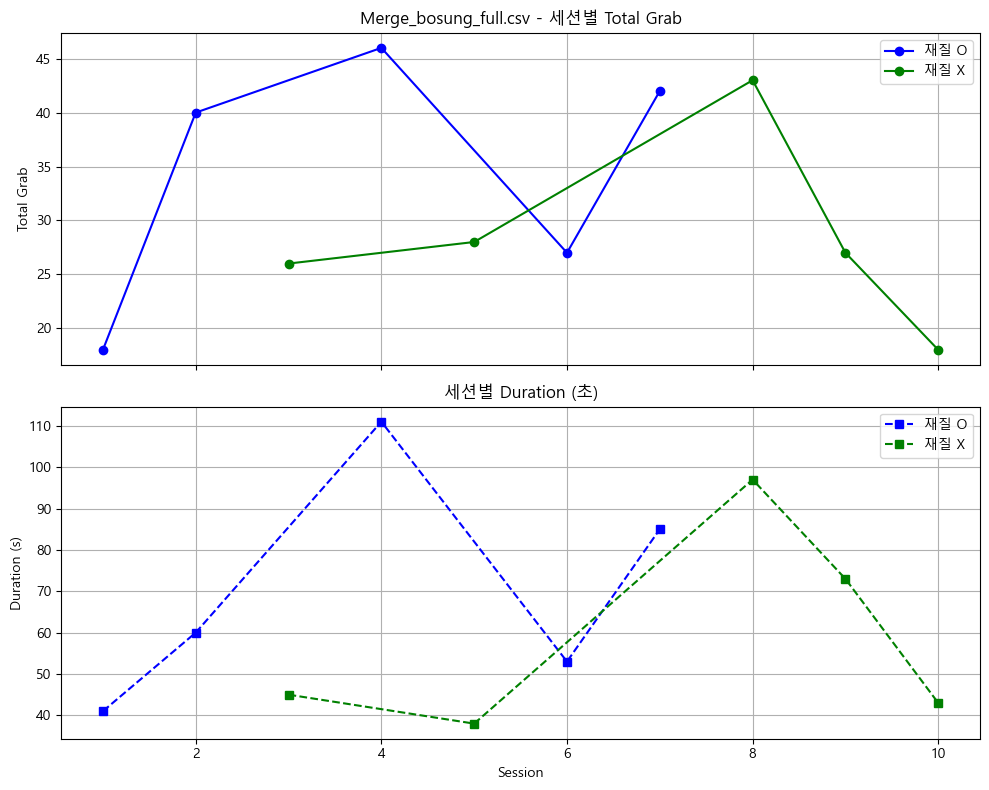


📄 파일: Merge_dohoon_full.csv
🧠 재질 O 평균 total_grab: 8.60
🔢 재질 X 평균 total_grab: 9.60
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 100.00%


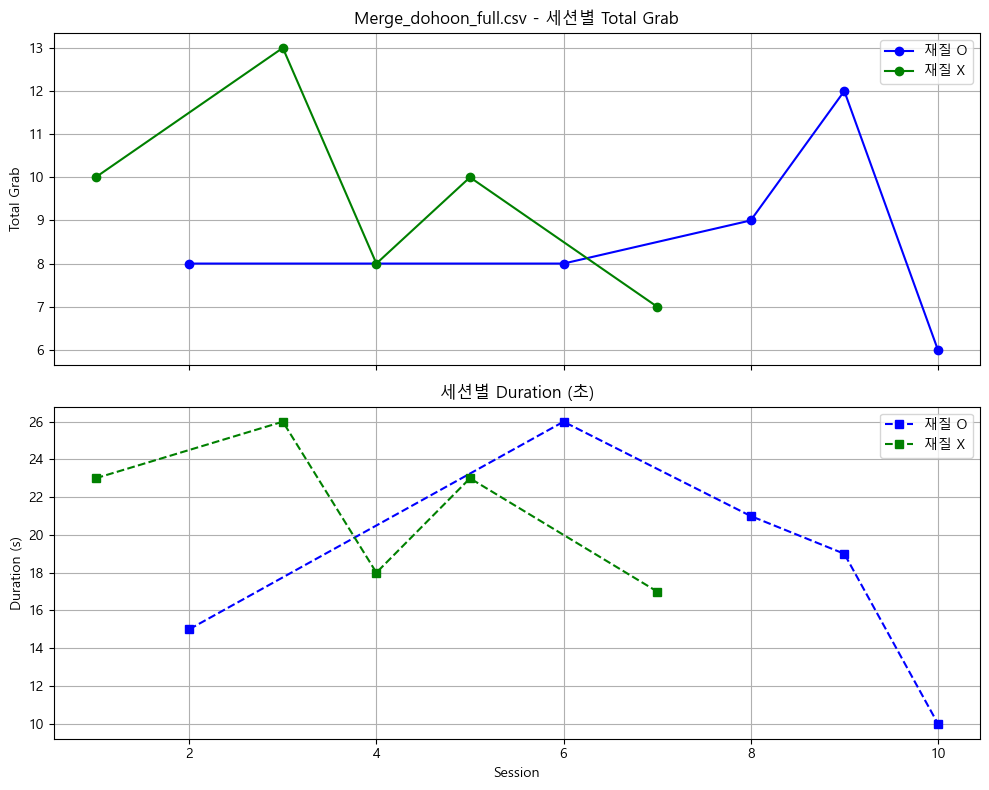


📄 파일: Merge_euncha_full.csv
🧠 재질 O 평균 total_grab: 32.40
🔢 재질 X 평균 total_grab: 25.00
🎯 평균 정확도 (%):
   🧠 재질 O: 76.00%
   🔢 재질 X: 32.00%


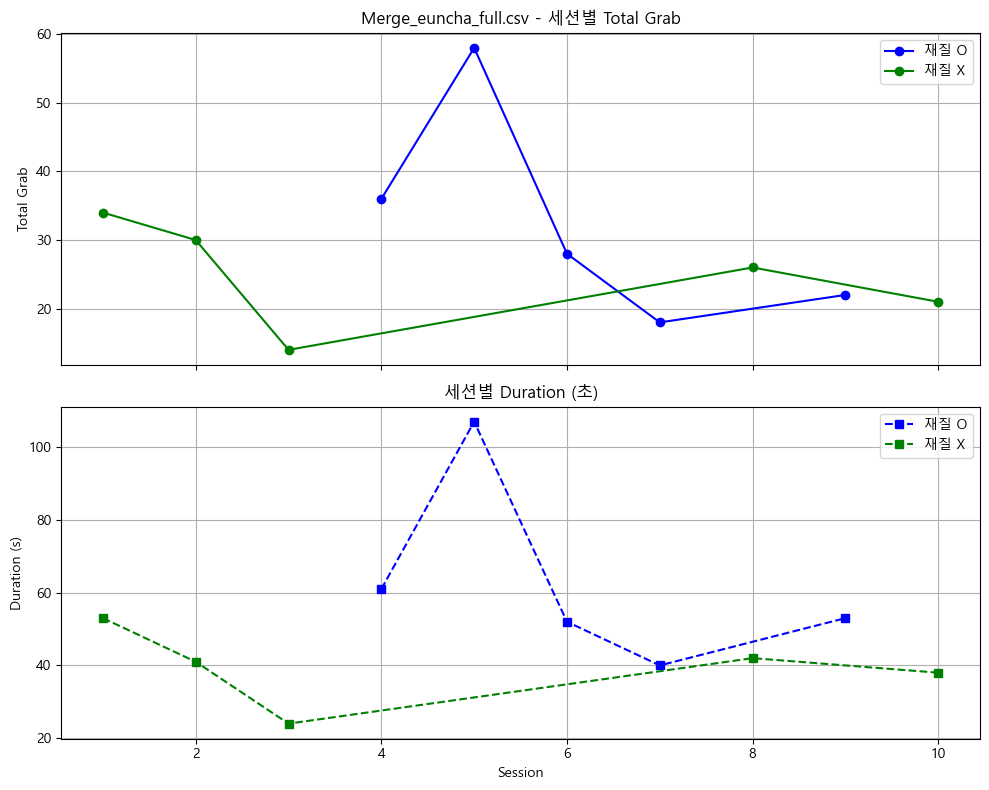


📄 파일: Merge_hyunwook_full.csv
🧠 재질 O 평균 total_grab: 8.60
🔢 재질 X 평균 total_grab: 13.20
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 100.00%


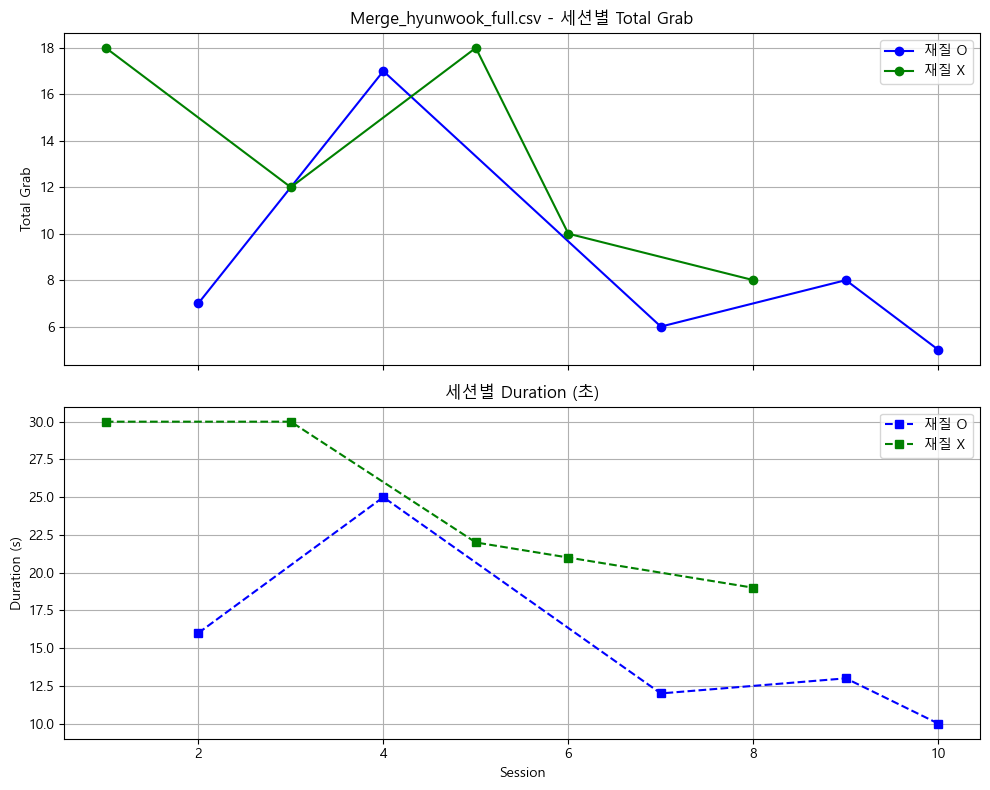


📄 파일: Merge_jaeho_full.csv
🧠 재질 O 평균 total_grab: 20.60
🔢 재질 X 평균 total_grab: 14.80
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 92.00%


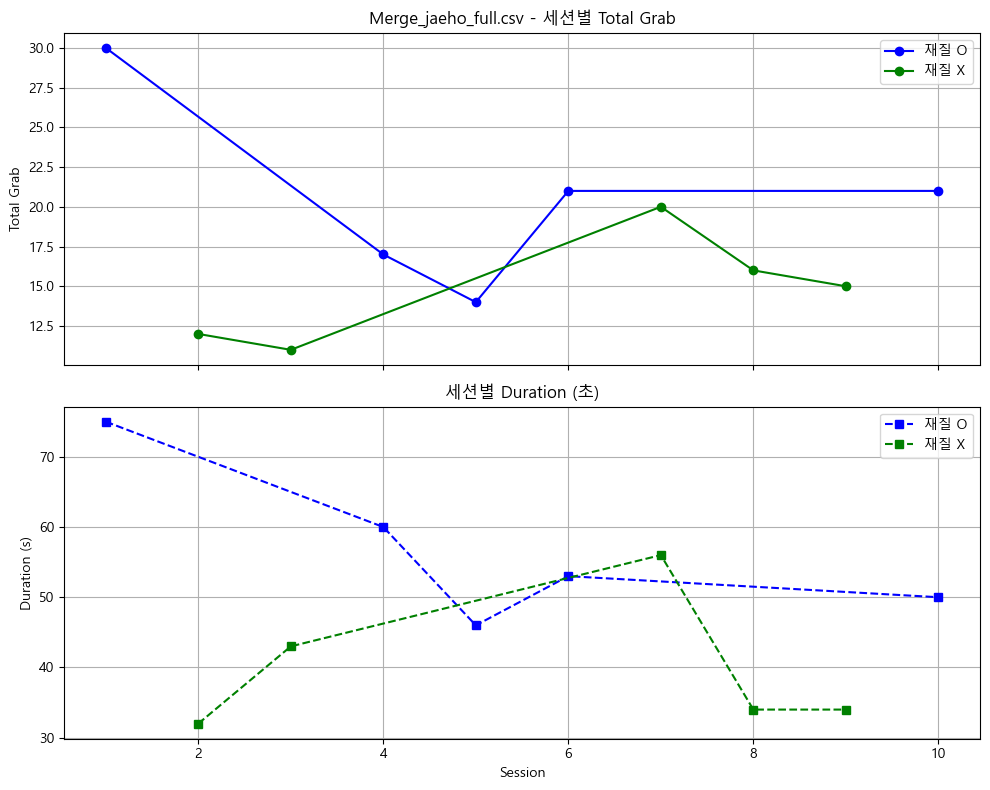


📄 파일: Merge_jaehu_full.csv
🧠 재질 O 평균 total_grab: 12.40
🔢 재질 X 평균 total_grab: 13.40
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 76.00%


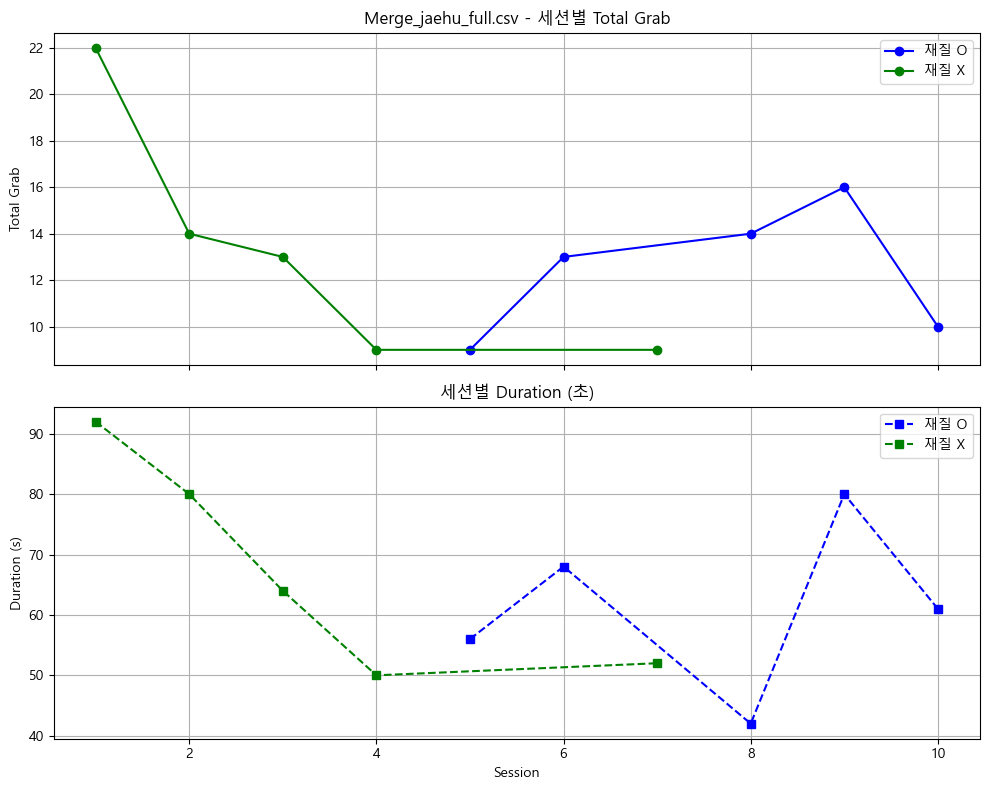


📄 파일: Merge_jinu_full.csv
🧠 재질 O 평균 total_grab: 26.00
🔢 재질 X 평균 total_grab: 30.20
🎯 평균 정확도 (%):
   🧠 재질 O: 64.00%
   🔢 재질 X: 40.00%


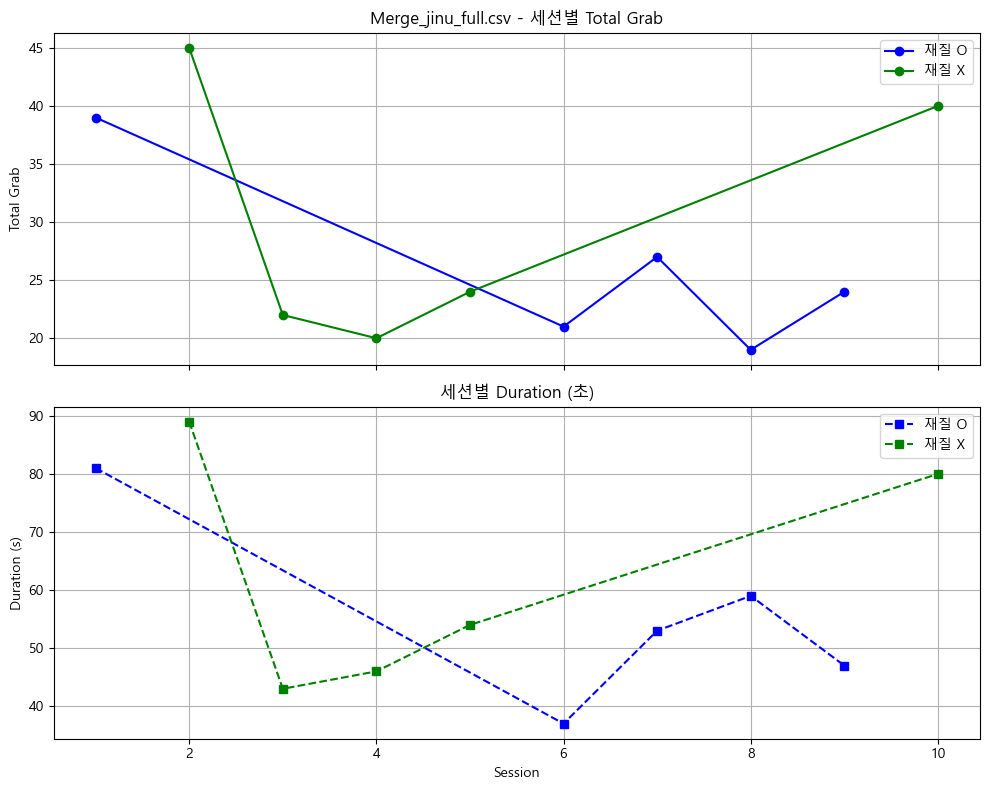


📄 파일: Merge_jiyoung_full.csv
🧠 재질 O 평균 total_grab: 19.00
🔢 재질 X 평균 total_grab: 10.40
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 92.00%


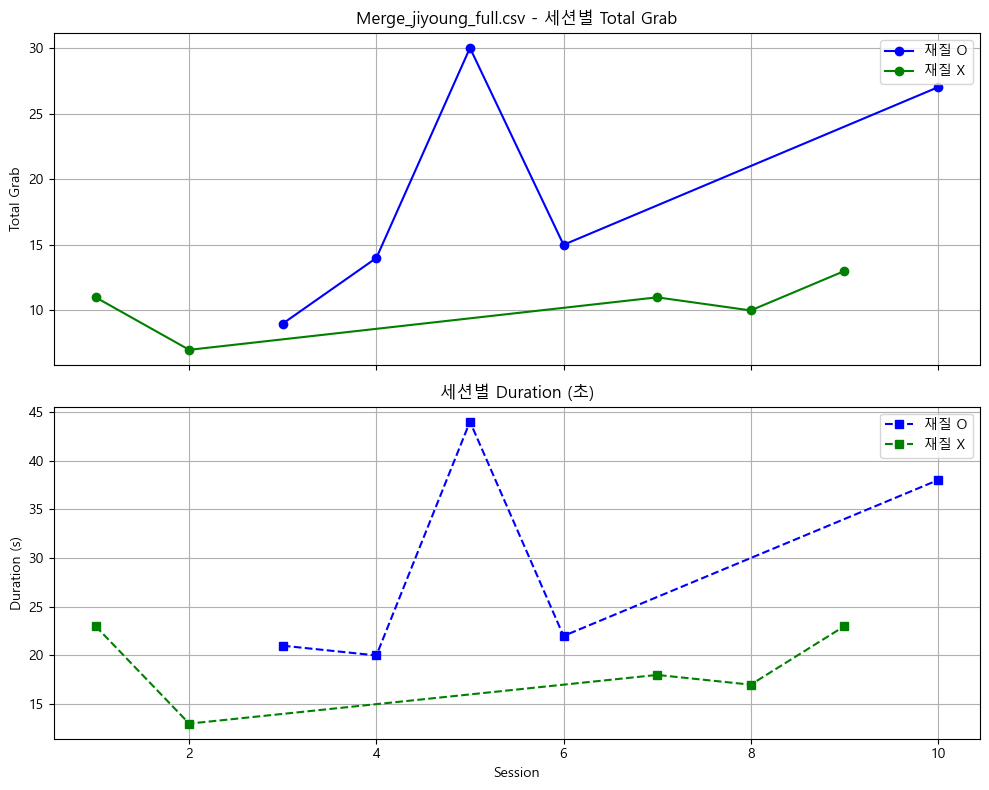


📄 파일: Merge_minho_full.csv
🧠 재질 O 평균 total_grab: 8.80
🔢 재질 X 평균 total_grab: 12.80
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 92.00%


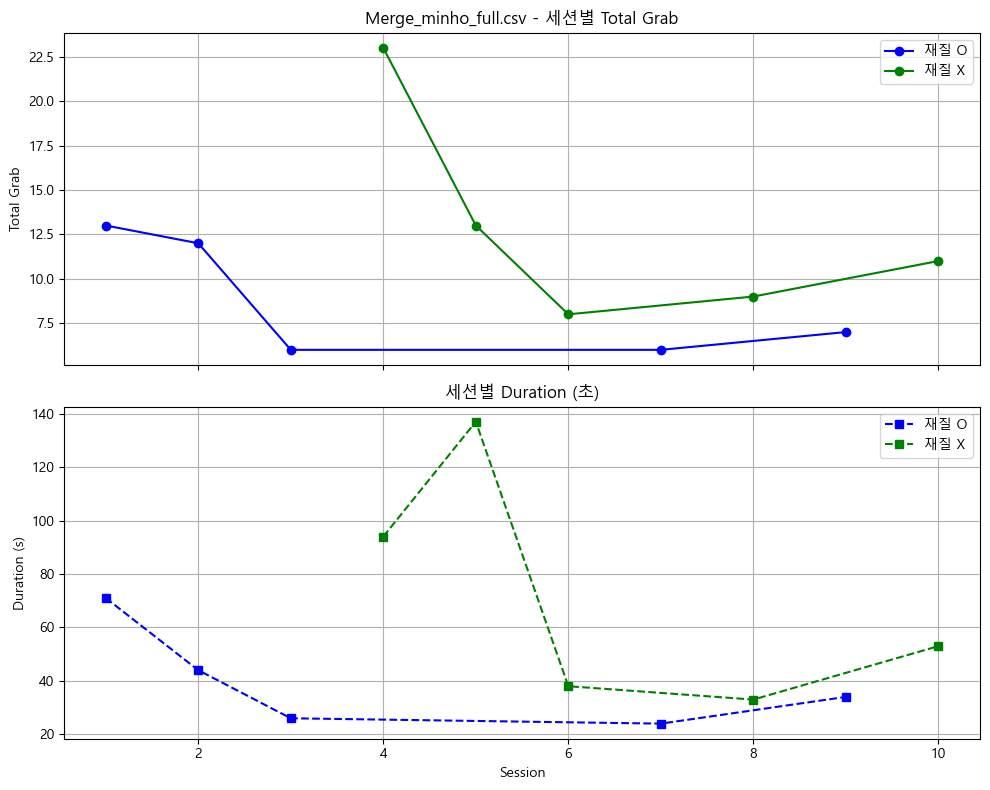


📄 파일: Merge_minju_full.csv
🧠 재질 O 평균 total_grab: 34.80
🔢 재질 X 평균 total_grab: 31.20
🎯 평균 정확도 (%):
   🧠 재질 O: 80.00%
   🔢 재질 X: 64.00%


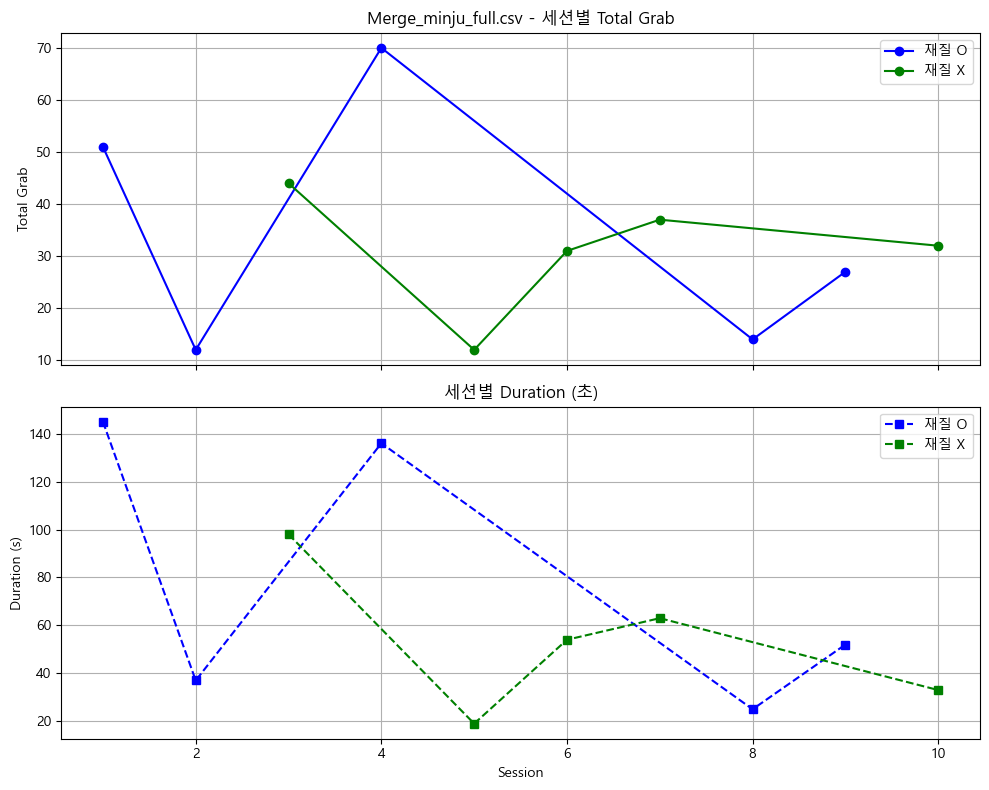


📄 파일: Merge_sarang_full.csv
🧠 재질 O 평균 total_grab: 25.40
🔢 재질 X 평균 total_grab: 29.40
🎯 평균 정확도 (%):
   🧠 재질 O: 60.00%
   🔢 재질 X: 24.00%


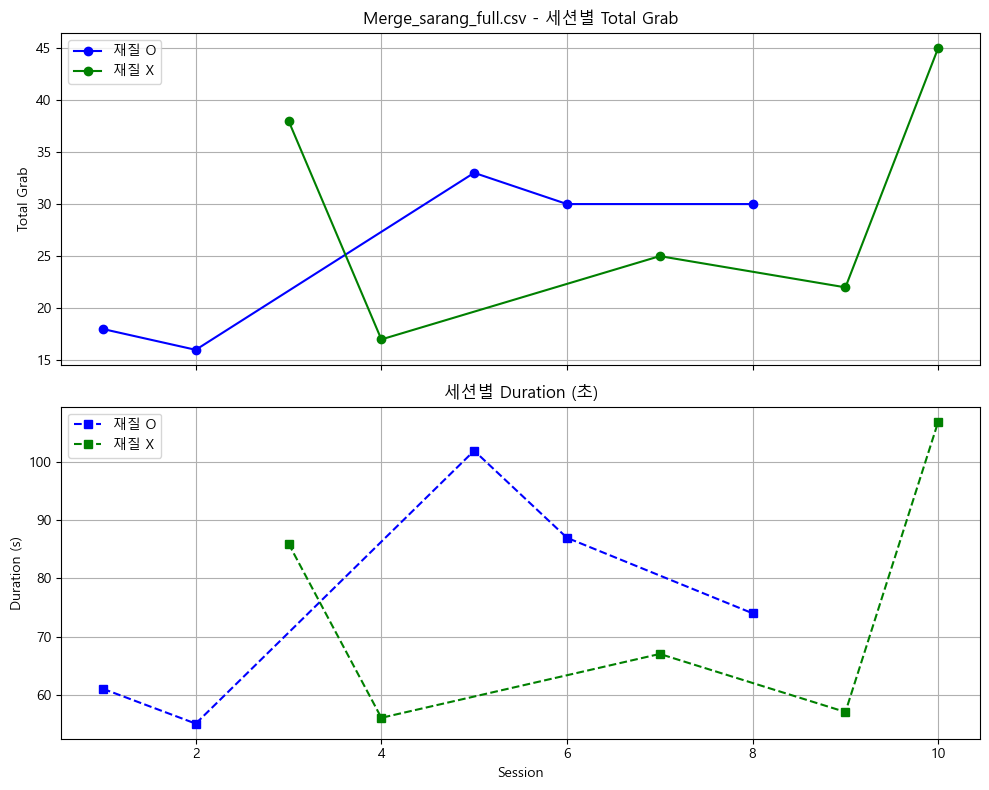


📄 파일: Merge_seongjun_full.csv
🧠 재질 O 평균 total_grab: 11.60
🔢 재질 X 평균 total_grab: 13.00
🎯 평균 정확도 (%):
   🧠 재질 O: 92.00%
   🔢 재질 X: 100.00%


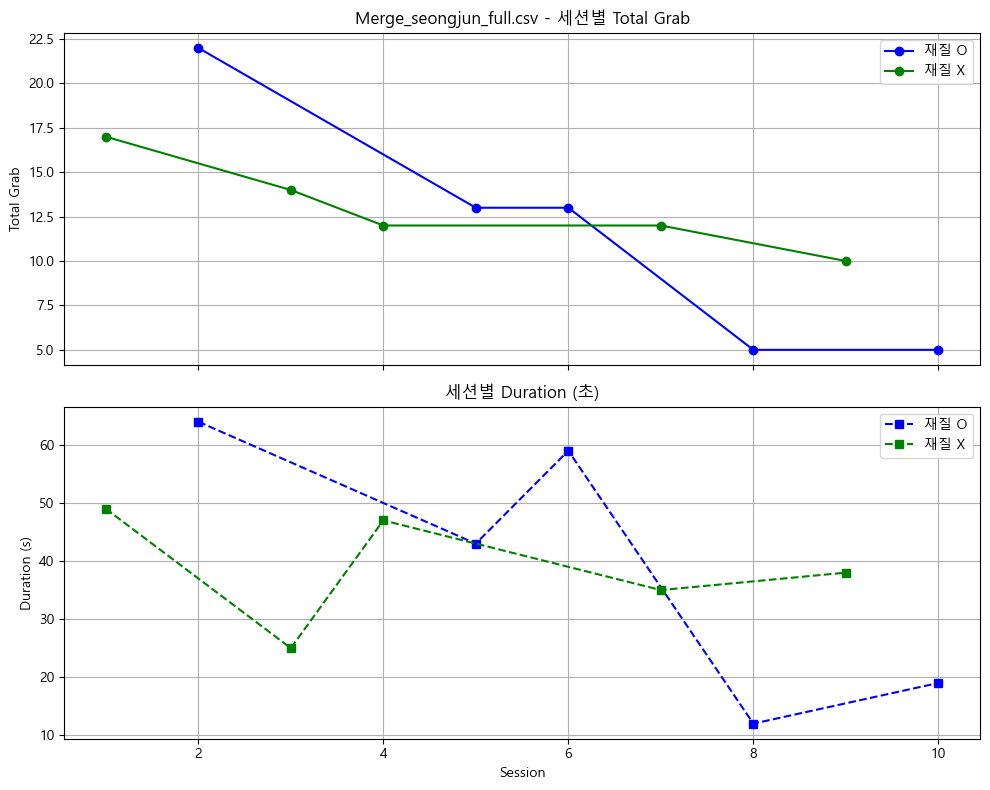


📄 파일: Merge_siu_full.csv
🧠 재질 O 평균 total_grab: 13.20
🔢 재질 X 평균 total_grab: 14.00
🎯 평균 정확도 (%):
   🧠 재질 O: 52.00%
   🔢 재질 X: 44.00%


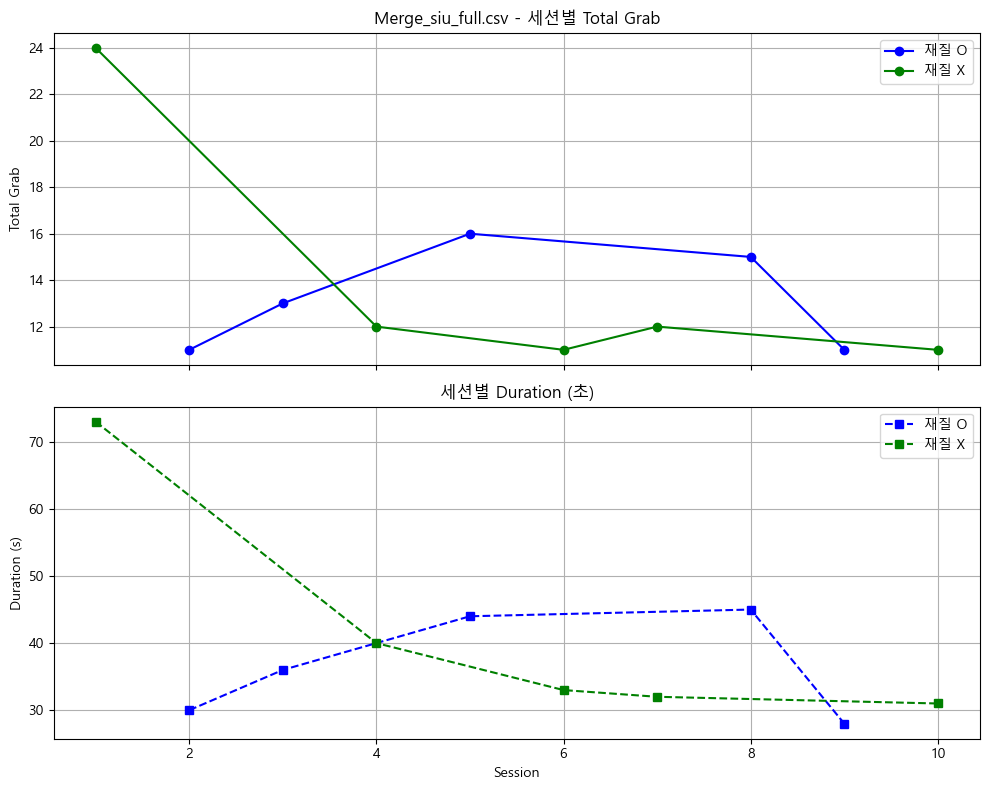


📄 파일: Merge_suhan_full.csv
🧠 재질 O 평균 total_grab: 15.60
🔢 재질 X 평균 total_grab: 22.80
🎯 평균 정확도 (%):
   🧠 재질 O: 52.00%
   🔢 재질 X: 48.00%


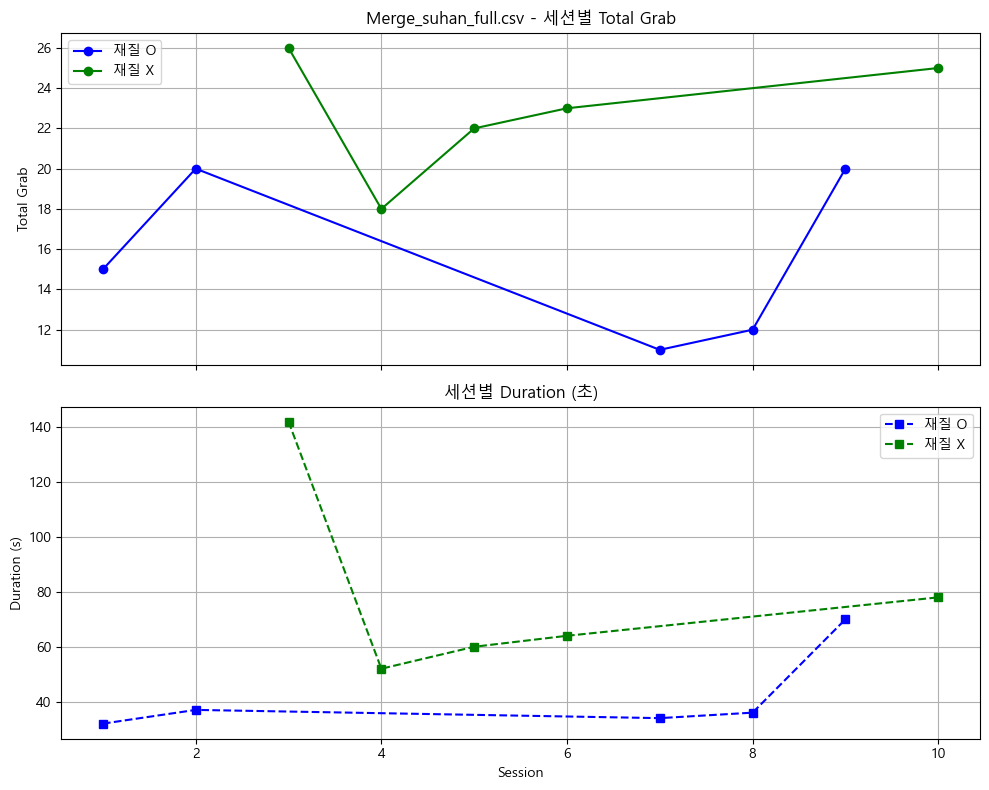


📄 파일: Merge_suyeoun_full.csv
🧠 재질 O 평균 total_grab: 10.60
🔢 재질 X 평균 total_grab: 10.80
🎯 평균 정확도 (%):
   🧠 재질 O: 76.00%
   🔢 재질 X: 76.00%


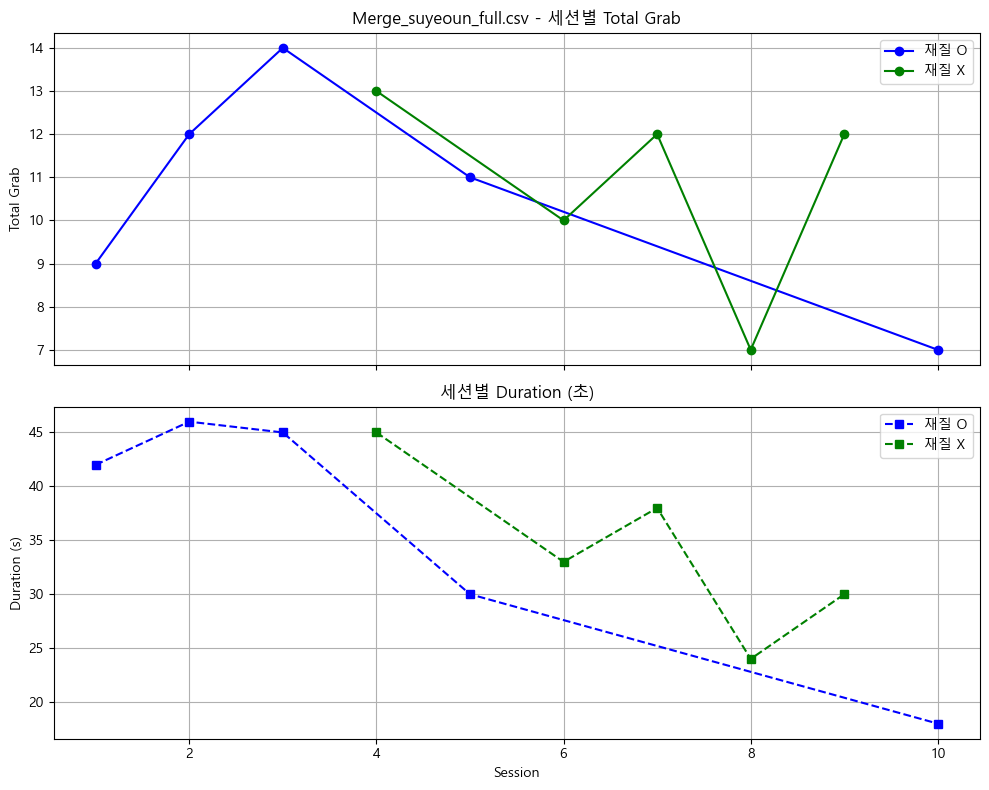


📄 파일: Merge_taeyoon_full.csv
🧠 재질 O 평균 total_grab: 13.20
🔢 재질 X 평균 total_grab: 17.40
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 100.00%


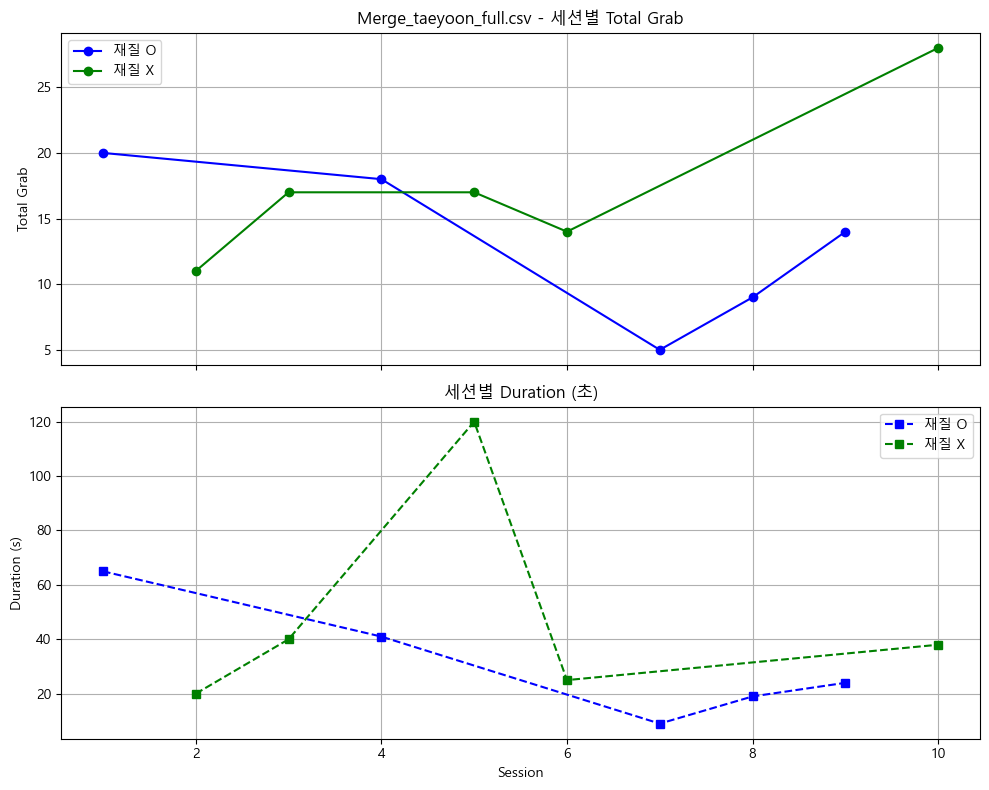


📄 파일: Merge_uiseong_full.csv
🧠 재질 O 평균 total_grab: 10.60
🔢 재질 X 평균 total_grab: 11.60
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 100.00%


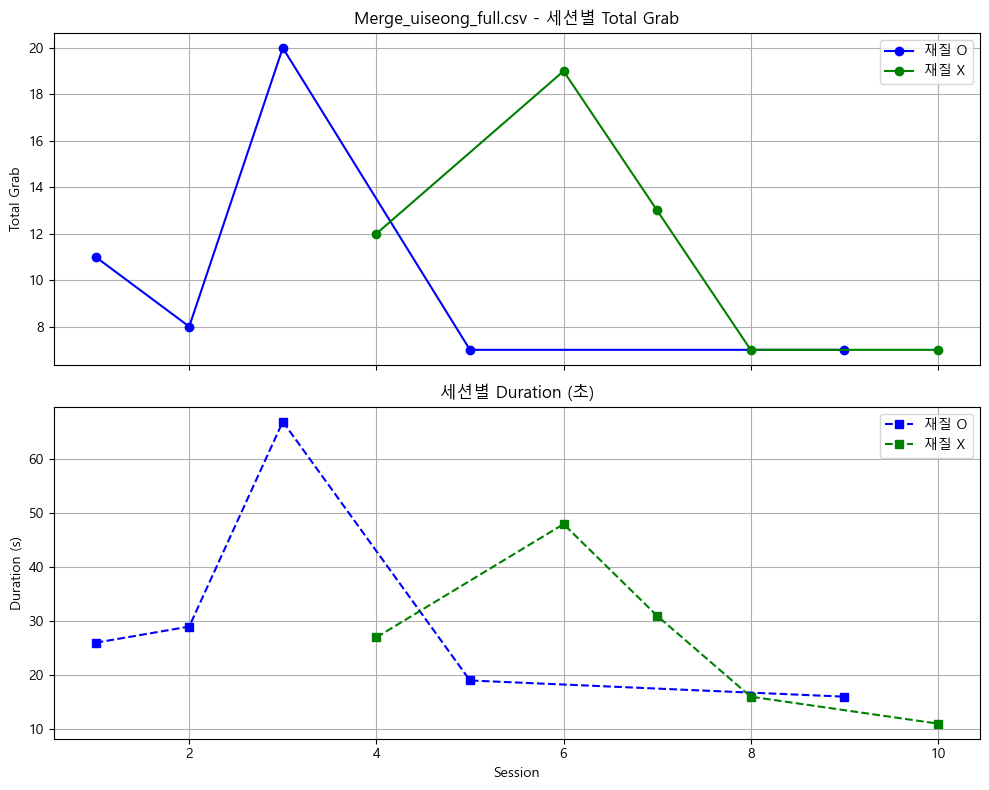


📄 파일: Merge_wonbin_full.csv
🧠 재질 O 평균 total_grab: 19.00
🔢 재질 X 평균 total_grab: 20.20
🎯 평균 정확도 (%):
   🧠 재질 O: 84.00%
   🔢 재질 X: 72.00%


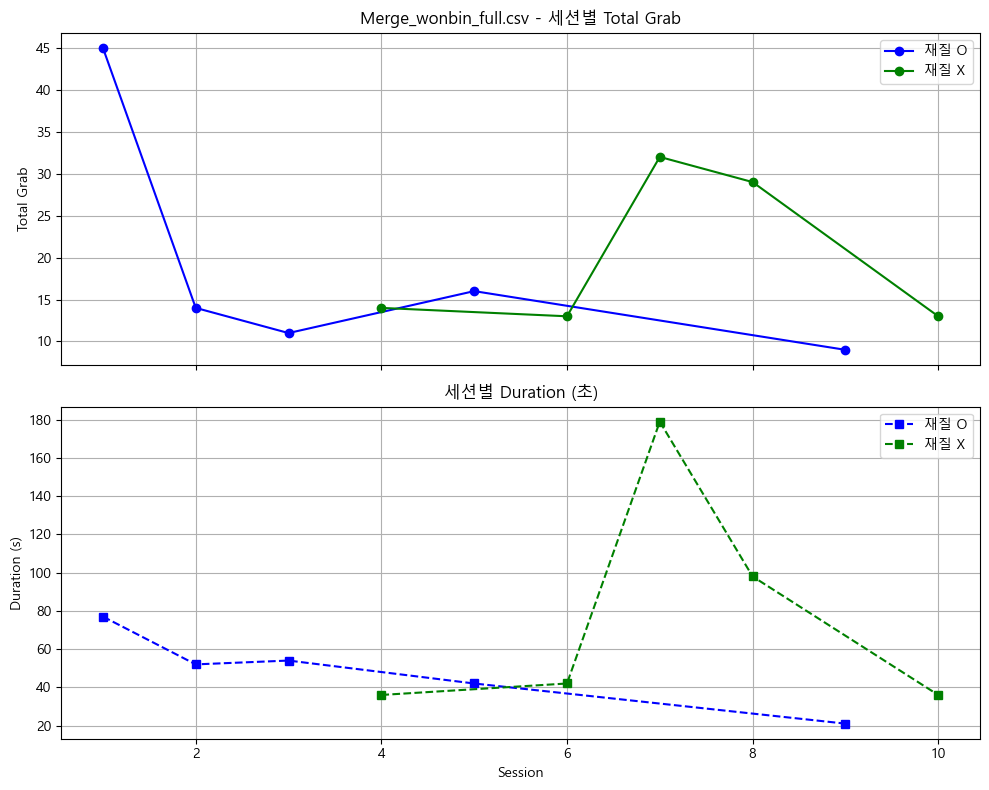


📄 파일: Merge_youngtaek_full.csv
🧠 재질 O 평균 total_grab: 23.20
🔢 재질 X 평균 total_grab: 32.00
🎯 평균 정확도 (%):
   🧠 재질 O: 64.00%
   🔢 재질 X: 52.00%


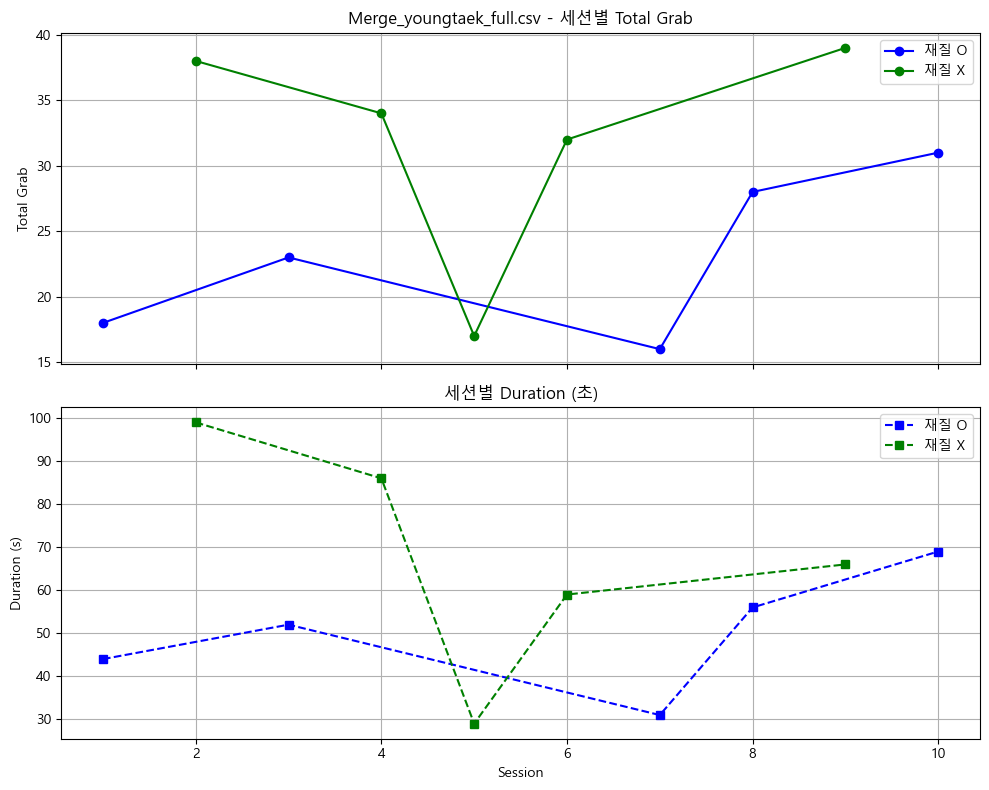


📄 파일: Merge_ys_full.csv
🧠 재질 O 평균 total_grab: 21.00
🔢 재질 X 평균 total_grab: 21.60
🎯 평균 정확도 (%):
   🧠 재질 O: 76.00%
   🔢 재질 X: 52.00%


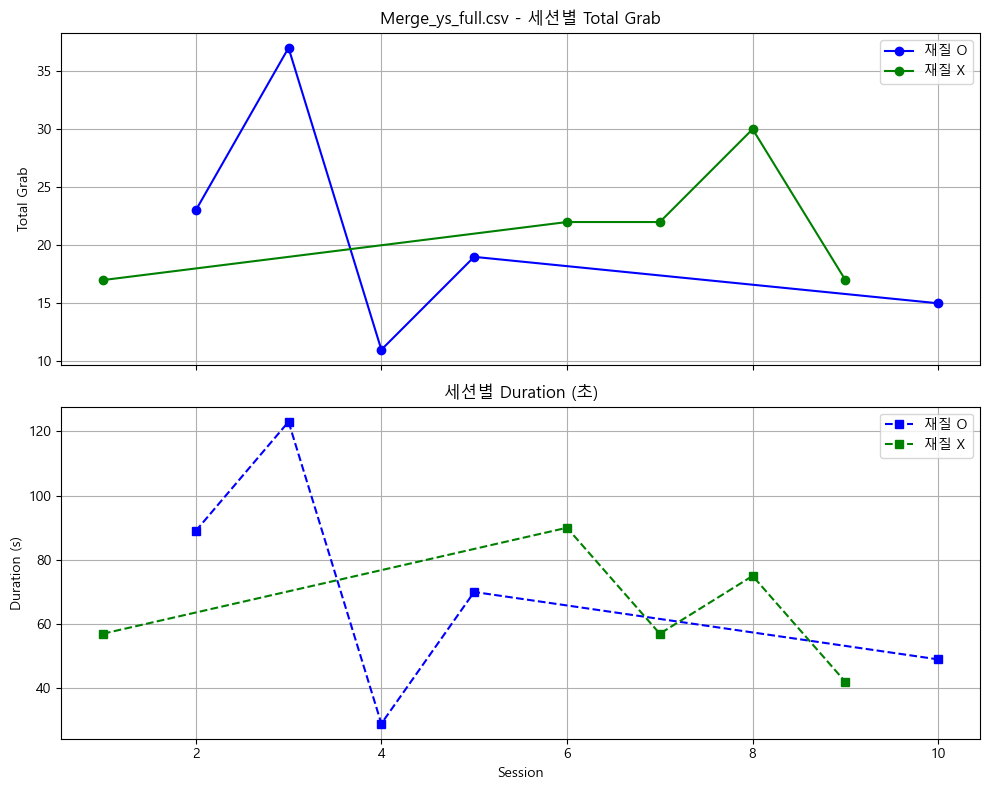


📦 전체 파일 기준 Grab 합계 및 Duration:
   🧠 재질 O 전체 Grab 합계: 1846
   🔢 재질 X 전체 Grab 합계: 1909
   🧠 재질 O 전체 Duration (s): 4759.00초
   🔢 재질 X 전체 Duration (s): 5057.00초

📊 평균 기준:
   🧠 재질 O 평균 Duration: 47.59초
   🔢 재질 X 평균 Duration: 50.57초
   🧠 재질 O 평균 Grab 횟수: 18.46
   🔢 재질 X 평균 Grab 횟수: 19.09

🎯 재질별 평균 정확도:
   🧠 재질 O 평균 정확도: 81.60%
   🔢 재질 X 평균 정확도: 71.00%


In [10]:
plot_total_grab("./Full")

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def print_detailed_accuracy_with_confusion(folder_path):
    all_df_list = []  # ✅ 전체 누적용

    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)

            # 전처리
            df = df.dropna(subset=["correct", "session", "object_name", "expected_zone", "zone"])
            df["correct"] = df["correct"].astype(bool)
            df["object_name"] = df["object_name"].astype(str)
            df["session"] = df["session"].astype(int)
            df["zone"] = df["zone"].astype(int)
            df["expected_zone"] = df["expected_zone"].astype(int)

            all_df_list.append(df)  # ✅ 누적

            # 세션별 정확도 출력
            results = []
            for session_id, session_df in df.groupby("session"):
                accuracy = session_df["correct"].mean() * 100
                object_type = classify_object_type(session_df)
                total_grab = session_df["total_grab"].dropna().iloc[-1] if not session_df["total_grab"].dropna().empty else None

                results.append({
                    "session": session_id,
                    "accuracy (%)": round(accuracy, 2),
                    "object_type": object_type,
                    "total_grab": int(total_grab) if pd.notnull(total_grab) else "N/A"
                })

            print(f"\n📄 파일: {file}")
            print(pd.DataFrame(results).to_string(index=False))
            print(f"📊 전체 정확도: {df['correct'].mean() * 100:.2f}%")

            # 혼동 행렬 출력 및 시각화
            labels = sorted(df["expected_zone"].unique())
            cm = confusion_matrix(df["expected_zone"], df["zone"], labels=labels)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
            disp.plot(cmap="Blues")
            plt.title(f"{file} - 혼동 행렬")
            plt.tight_layout()
            plt.show()

    # ✅ 전체 데이터 누적 후 전체 혼동 행렬 시각화
    if all_df_list:
        full_df = pd.concat(all_df_list, ignore_index=True)
        print("\n📦 전체 파일 기준 혼동 행렬:")

        labels = sorted(full_df["expected_zone"].unique())
        cm_all = confusion_matrix(full_df["expected_zone"], full_df["zone"], labels=labels)

        cm_df_all = pd.DataFrame(cm_all, index=[f"GT_{i}" for i in labels], columns=[f"P_{i}" for i in labels])
        print(cm_df_all)

        disp_all = ConfusionMatrixDisplay(confusion_matrix=cm_all, display_labels=labels)
        disp_all.plot(cmap="Oranges")
        plt.title("전체 파일 기준 혼동 행렬")
        plt.tight_layout()
        plt.show()



📄 파일: Merge_bosung_full.csv
 session  accuracy (%) object_type  total_grab
       1          60.0        재질 O          18
       2          60.0        재질 O          40
       3          60.0        재질 X          26
       4          40.0        재질 O          46
       5          40.0        재질 X          28
       6          60.0        재질 O          27
       7          60.0        재질 O          42
       8          60.0        재질 X          43
       9          60.0        재질 X          27
      10         100.0        재질 X          18
📊 전체 정확도: 60.00%


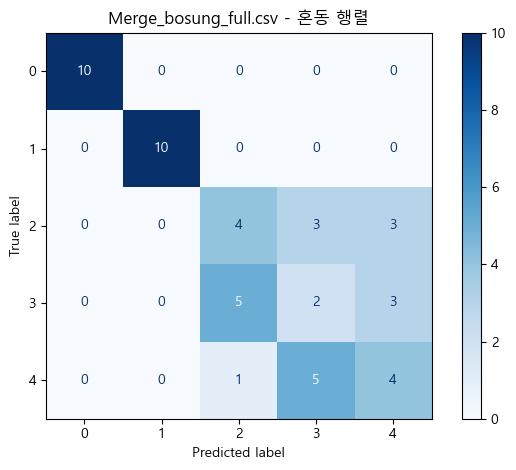


📄 파일: Merge_dohoon_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 X          10
       2         100.0        재질 O           8
       3         100.0        재질 X          13
       4         100.0        재질 X           8
       5         100.0        재질 X          10
       6         100.0        재질 O           8
       7         100.0        재질 X           7
       8         100.0        재질 O           9
       9         100.0        재질 O          12
      10         100.0        재질 O           6
📊 전체 정확도: 100.00%


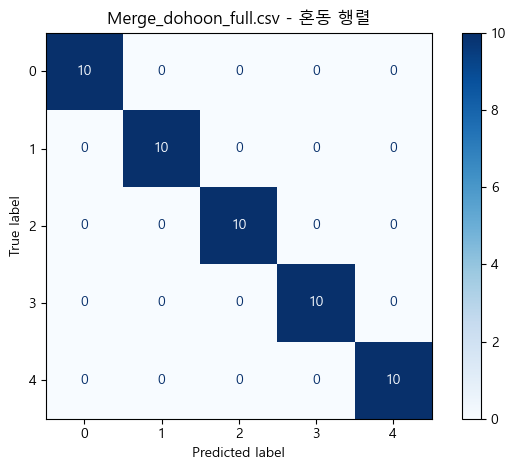


📄 파일: Merge_euncha_full.csv
 session  accuracy (%) object_type  total_grab
       1          20.0        재질 X          34
       2          40.0        재질 X          30
       3          20.0        재질 X          14
       4         100.0        재질 O          36
       5          60.0        재질 O          58
       6          60.0        재질 O          28
       7          60.0        재질 O          18
       8          40.0        재질 X          26
       9         100.0        재질 O          22
      10          40.0        재질 X          21
📊 전체 정확도: 54.00%


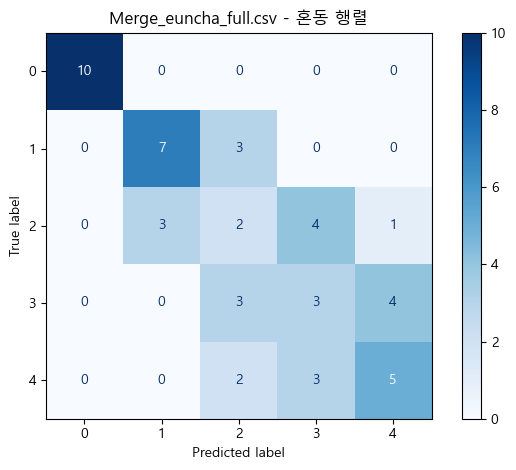


📄 파일: Merge_hyunwook_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 X          18
       2         100.0        재질 O           7
       3         100.0        재질 X          12
       4         100.0        재질 O          17
       5         100.0        재질 X          18
       6         100.0        재질 X          10
       7         100.0        재질 O           6
       8         100.0        재질 X           8
       9         100.0        재질 O           8
      10         100.0        재질 O           5
📊 전체 정확도: 100.00%


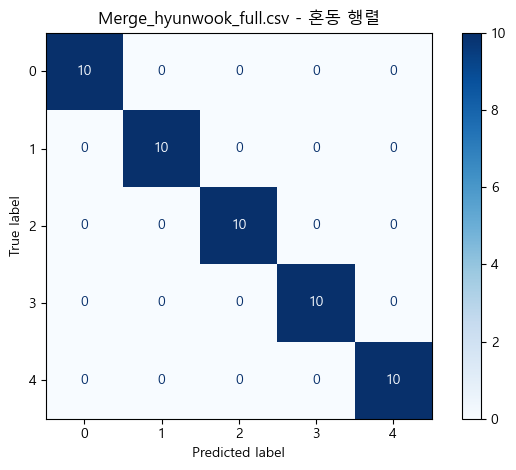


📄 파일: Merge_jaeho_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 O          30
       2          60.0        재질 X          12
       3         100.0        재질 X          11
       4         100.0        재질 O          17
       5         100.0        재질 O          14
       6         100.0        재질 O          21
       7         100.0        재질 X          20
       8         100.0        재질 X          16
       9         100.0        재질 X          15
      10         100.0        재질 O          21
📊 전체 정확도: 96.00%


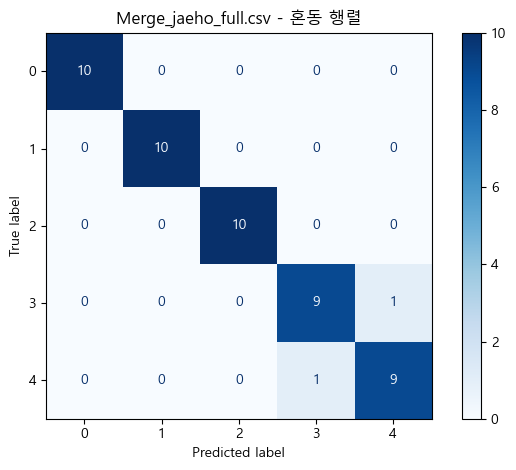


📄 파일: Merge_jaehu_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 X          22
       2          60.0        재질 X          14
       3          60.0        재질 X          13
       4          60.0        재질 X           9
       5         100.0        재질 O           9
       6         100.0        재질 O          13
       7         100.0        재질 X           9
       8         100.0        재질 O          14
       9         100.0        재질 O          16
      10         100.0        재질 O          10
📊 전체 정확도: 88.00%


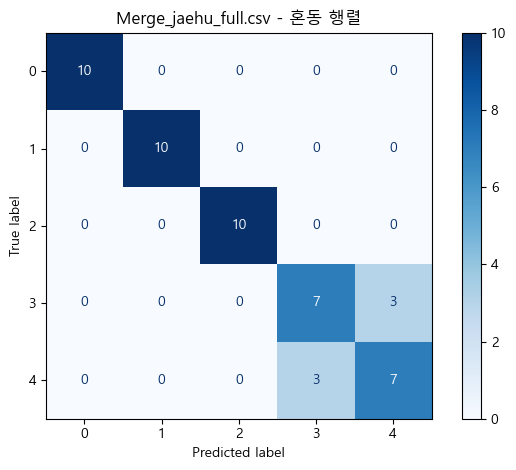


📄 파일: Merge_jinu_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 O          39
       2          40.0        재질 X          45
       3          20.0        재질 X          22
       4          40.0        재질 X          20
       5          60.0        재질 X          24
       6         100.0        재질 O          21
       7          40.0        재질 O          27
       8          60.0        재질 O          19
       9          20.0        재질 O          24
      10          40.0        재질 X          40
📊 전체 정확도: 52.00%


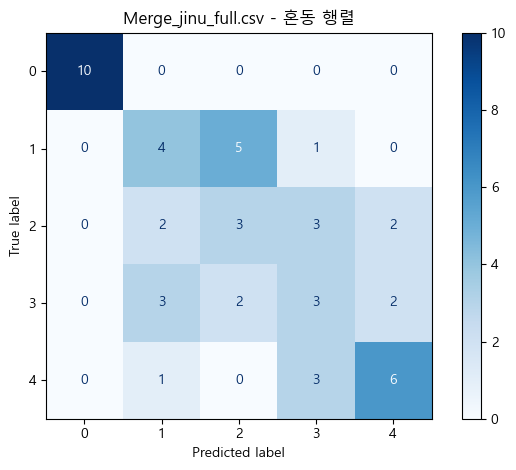


📄 파일: Merge_jiyoung_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 X          11
       2         100.0        재질 X           7
       3         100.0        재질 O           9
       4         100.0        재질 O          14
       5         100.0        재질 O          30
       6         100.0        재질 O          15
       7          60.0        재질 X          11
       8         100.0        재질 X          10
       9         100.0        재질 X          13
      10         100.0        재질 O          27
📊 전체 정확도: 96.00%


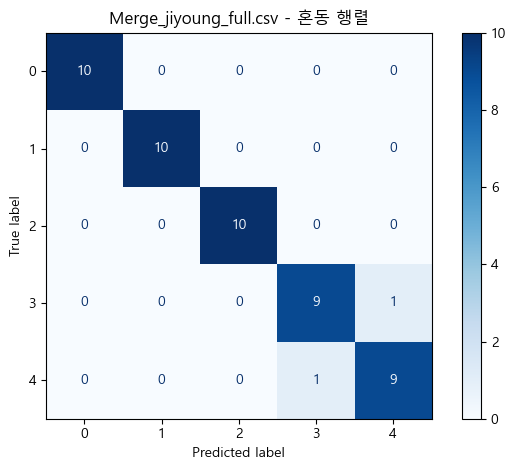


📄 파일: Merge_minho_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 O          13
       2         100.0        재질 O          12
       3         100.0        재질 O           6
       4          60.0        재질 X          23
       5         100.0        재질 X          13
       6         100.0        재질 X           8
       7         100.0        재질 O           6
       8         100.0        재질 X           9
       9         100.0        재질 O           7
      10         100.0        재질 X          11
📊 전체 정확도: 96.00%


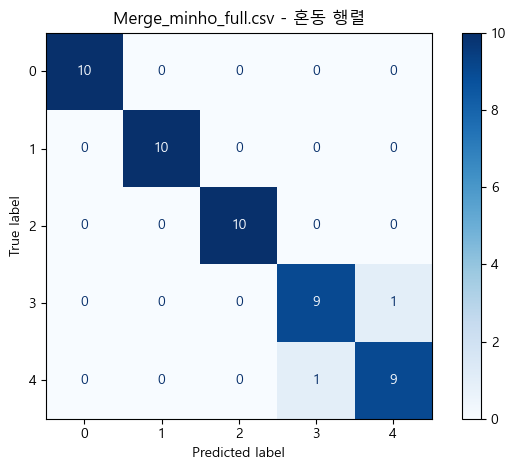


📄 파일: Merge_minju_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 O          51
       2         100.0        재질 O          12
       3          60.0        재질 X          44
       4          40.0        재질 O          70
       5          40.0        재질 X          12
       6          60.0        재질 X          31
       7          60.0        재질 X          37
       8         100.0        재질 O          14
       9          60.0        재질 O          27
      10         100.0        재질 X          32
📊 전체 정확도: 72.00%


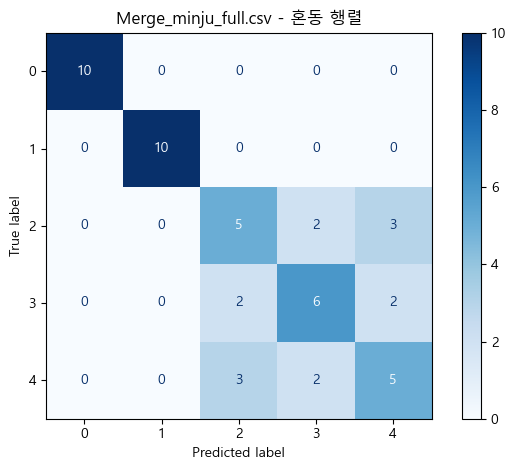


📄 파일: Merge_sarang_full.csv
 session  accuracy (%) object_type  total_grab
       1          20.0        재질 O          18
       2         100.0        재질 O          16
       3          20.0        재질 X          38
       4          20.0        재질 X          17
       5          20.0        재질 O          33
       6          60.0        재질 O          30
       7          20.0        재질 X          25
       8         100.0        재질 O          30
       9          40.0        재질 X          22
      10          20.0        재질 X          45
📊 전체 정확도: 42.00%


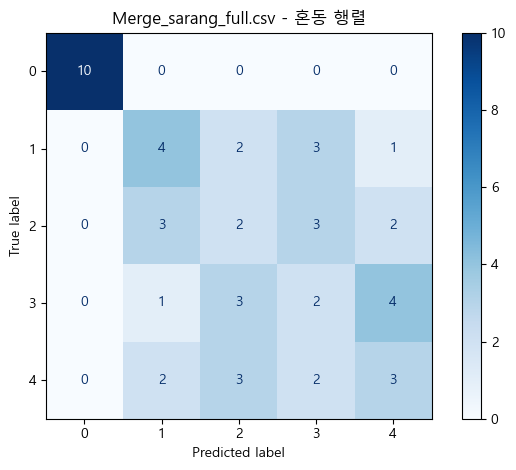


📄 파일: Merge_seongjun_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 X          17
       2         100.0        재질 O          22
       3         100.0        재질 X          14
       4         100.0        재질 X          12
       5          60.0        재질 O          13
       6         100.0        재질 O          13
       7         100.0        재질 X          12
       8         100.0        재질 O           5
       9         100.0        재질 X          10
      10         100.0        재질 O           5
📊 전체 정확도: 96.00%


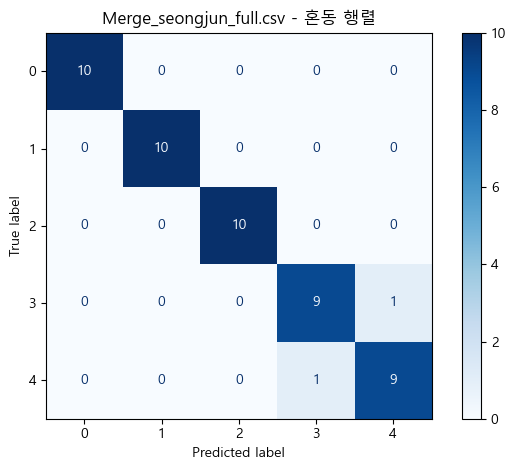


📄 파일: Merge_siu_full.csv
 session  accuracy (%) object_type  total_grab
       1          40.0        재질 X          24
       2         100.0        재질 O          11
       3          60.0        재질 O          13
       4          20.0        재질 X          12
       5          20.0        재질 O          16
       6          60.0        재질 X          11
       7          60.0        재질 X          12
       8          60.0        재질 O          15
       9          20.0        재질 O          11
      10          40.0        재질 X          11
📊 전체 정확도: 48.00%


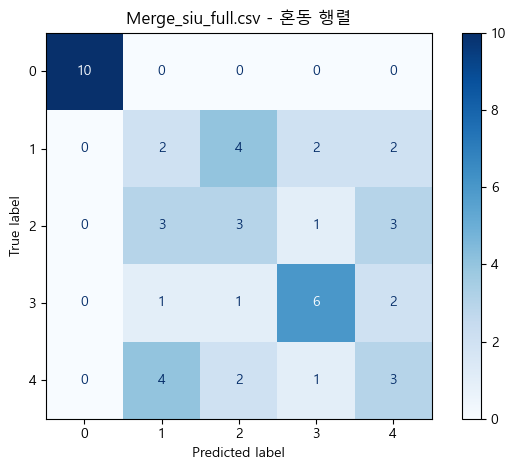


📄 파일: Merge_suhan_full.csv
 session  accuracy (%) object_type  total_grab
       1          60.0        재질 O          15
       2          60.0        재질 O          20
       3          60.0        재질 X          26
       4         100.0        재질 X          18
       5          40.0        재질 X          22
       6          20.0        재질 X          23
       7          60.0        재질 O          11
       8          60.0        재질 O          12
       9          20.0        재질 O          20
      10          20.0        재질 X          25
📊 전체 정확도: 50.00%


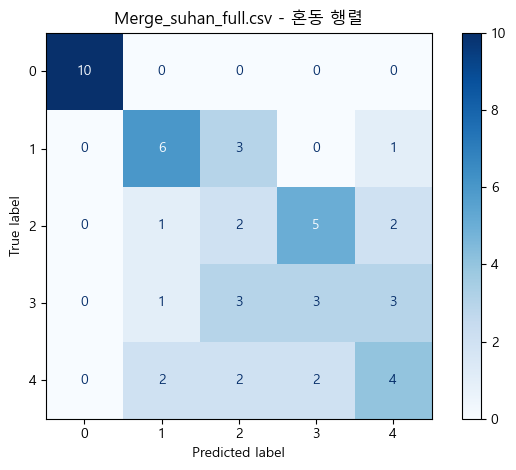


📄 파일: Merge_suyeoun_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 O           9
       2          60.0        재질 O          12
       3         100.0        재질 O          14
       4          60.0        재질 X          13
       5          60.0        재질 O          11
       6          60.0        재질 X          10
       7         100.0        재질 X          12
       8         100.0        재질 X           7
       9          60.0        재질 X          12
      10          60.0        재질 O           7
📊 전체 정확도: 76.00%


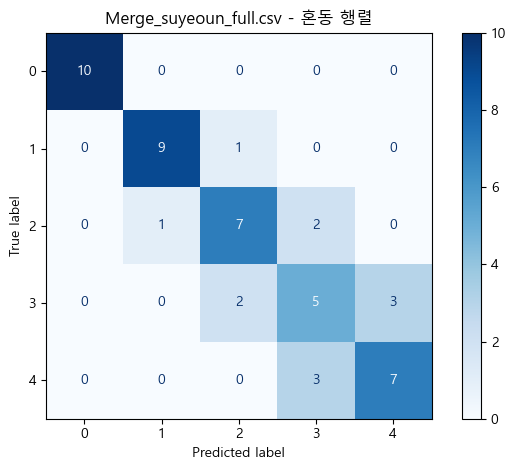


📄 파일: Merge_taeyoon_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 O          20
       2         100.0        재질 X          11
       3         100.0        재질 X          17
       4         100.0        재질 O          18
       5         100.0        재질 X          17
       6         100.0        재질 X          14
       7         100.0        재질 O           5
       8         100.0        재질 O           9
       9         100.0        재질 O          14
      10         100.0        재질 X          28
📊 전체 정확도: 100.00%


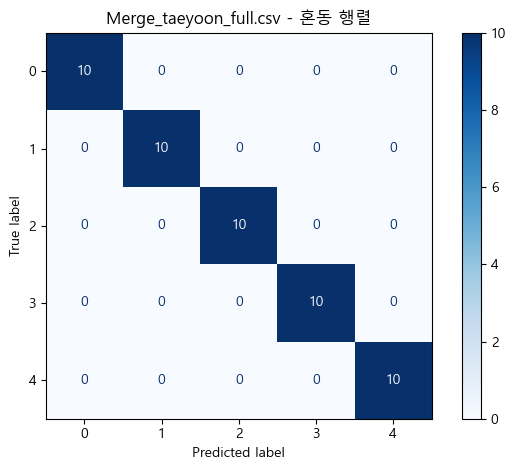


📄 파일: Merge_uiseong_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 O          11
       2         100.0        재질 O           8
       3         100.0        재질 O          20
       4         100.0        재질 X          12
       5         100.0        재질 O           7
       6         100.0        재질 X          19
       7         100.0        재질 X          13
       8         100.0        재질 X           7
       9         100.0        재질 O           7
      10         100.0        재질 X           7
📊 전체 정확도: 100.00%


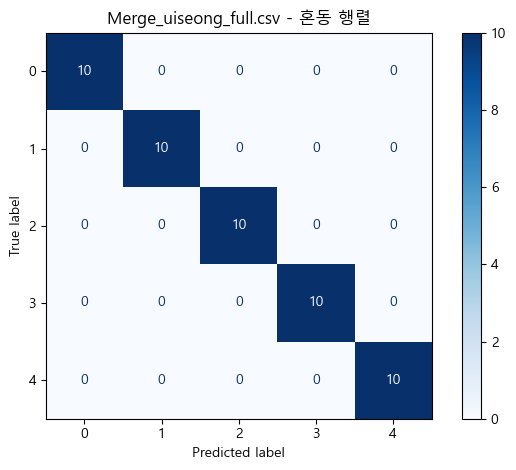


📄 파일: Merge_wonbin_full.csv
 session  accuracy (%) object_type  total_grab
       1          60.0        재질 O          45
       2         100.0        재질 O          14
       3         100.0        재질 O          11
       4         100.0        재질 X          14
       5          60.0        재질 O          16
       6         100.0        재질 X          13
       7          40.0        재질 X          32
       8          60.0        재질 X          29
       9         100.0        재질 O           9
      10          60.0        재질 X          13
📊 전체 정확도: 78.00%


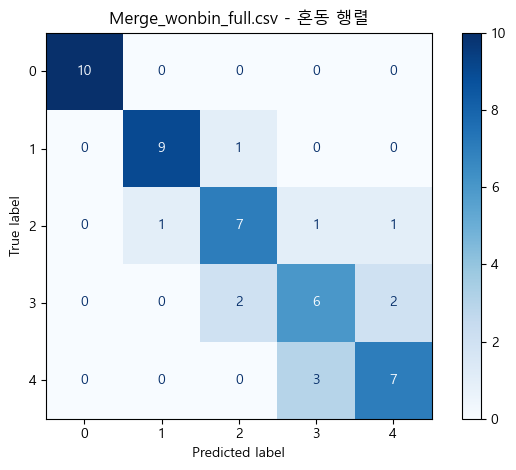


📄 파일: Merge_youngtaek_full.csv
 session  accuracy (%) object_type  total_grab
       1          40.0        재질 O          18
       2          60.0        재질 X          38
       3          60.0        재질 O          23
       4          60.0        재질 X          34
       5          60.0        재질 X          17
       6          40.0        재질 X          32
       7         100.0        재질 O          16
       8          60.0        재질 O          28
       9          40.0        재질 X          39
      10          60.0        재질 O          31
📊 전체 정확도: 58.00%


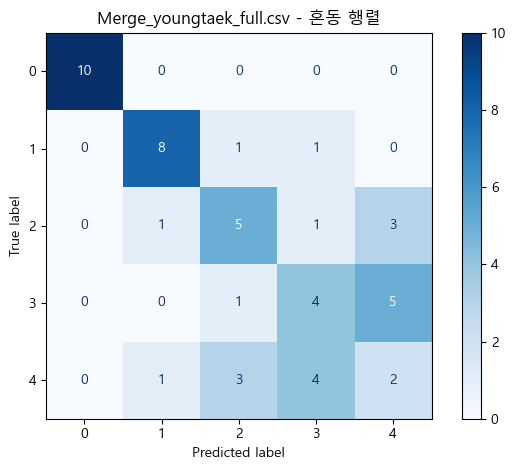


📄 파일: Merge_ys_full.csv
 session  accuracy (%) object_type  total_grab
       1          60.0        재질 X          17
       2          60.0        재질 O          23
       3         100.0        재질 O          37
       4          60.0        재질 O          11
       5          60.0        재질 O          19
       6          60.0        재질 X          22
       7          60.0        재질 X          22
       8          20.0        재질 X          30
       9          60.0        재질 X          17
      10         100.0        재질 O          15
📊 전체 정확도: 64.00%


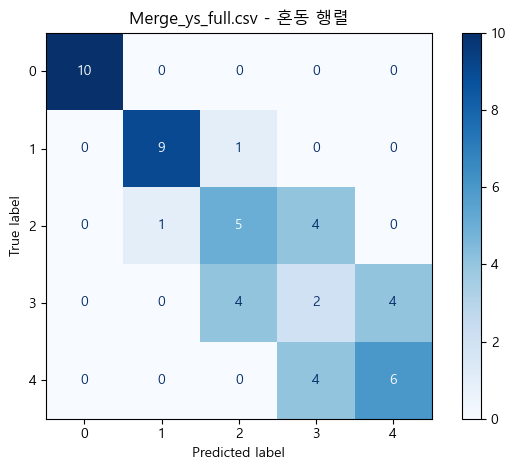


📦 전체 파일 기준 혼동 행렬:
      P_0  P_1  P_2  P_3  P_4
GT_0  200    0    0    0    0
GT_1    0  168   21    7    4
GT_2    0   16  135   29   20
GT_3    0    6   28  125   41
GT_4    0   10   16   39  135


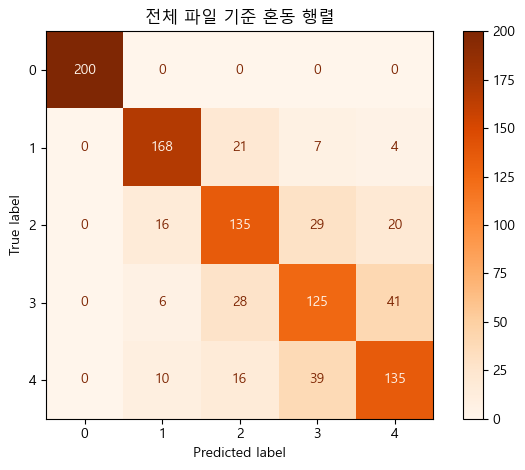

In [12]:
print_detailed_accuracy_with_confusion("./Full")

In [13]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

def summarize_object_grab_by_type_with_plot(folder_path):
    english_objects = ["Fur ball", "Sponge ball", "bouncy ball", "BaseBall", "Steal ball"]
    number_objects = ["0", "10", "30", "50", "100"]

    all_data = []

    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            try:
                df = pd.read_csv(file_path)
                df["object_name"] = df["object_name"].astype(str)
                df["object_grab"] = pd.to_numeric(df["object_grab"], errors="coerce")

                def classify(obj):
                    if obj in english_objects:
                        return "재질 O"
                    elif obj in number_objects:
                        return "재질 X"
                    else:
                        return "기타"

                df["material_type"] = df["object_name"].apply(classify)
                all_data.append(df)

                print(f"\n📄 파일: {file}")

                # for label, emoji in [("재질 O", "🧠"), ("재질 X", "🔢")]:
                #     sub_df = df[df["material_type"] == label]
                #     total_grab_sum = sub_df["object_grab"].sum()
                #     print(f"{emoji} {label} 합계: {int(total_grab_sum)}")
                #     grouped = sub_df.groupby("object_name")["object_grab"].sum()
                #     for obj, grab_sum in grouped.items():
                #         print(f" - {obj}: grab {int(grab_sum)}")

            except Exception as e:
                print(f"⚠️ 오류 발생: {file} → {e}")

    if all_data:
        total_df = pd.concat(all_data, ignore_index=True)

        # 📊 재질별 데이터
        eng_df = total_df[total_df["material_type"] == "재질 O"]
        num_df = total_df[total_df["material_type"] == "재질 X"]

        eng_grab = eng_df.groupby("object_name")["object_grab"].sum().reindex(english_objects).fillna(0)
        num_grab = num_df.groupby("object_name")["object_grab"].sum().reindex(number_objects).fillna(0)

        # # === 개별 그래프: 재질 O
        # plt.figure(figsize=(8, 4))
        # eng_grab.plot(kind="bar", color="skyblue")
        # plt.title("재질 O 오브젝트별 Grab 합계")
        # plt.xlabel("Object Name")
        # plt.ylabel("Grab 합계")
        # plt.ylim(0, 300)
        # plt.yticks(np.arange(0, 301, 25))
        # plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        # plt.tight_layout()
        # plt.show()

        # # === 개별 그래프: 재질 X
        # plt.figure(figsize=(8, 4))
        # num_grab.plot(kind="bar", color="lightcoral")
        # plt.title("재질 X 오브젝트별 Grab 합계")
        # plt.xlabel("Object Name")
        # plt.ylabel("Grab 합계")
        # plt.ylim(0, 300)
        # plt.yticks(np.arange(0, 301, 25))
        # plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        # plt.tight_layout()
        # plt.show()

        # # === 선 그래프: 재질 O & X 비교
        # plt.figure(figsize=(10, 5))
        # plt.plot(english_objects, eng_grab.values, marker='o', label="재질 O", color="blue")
        # plt.plot(number_objects, num_grab.values, marker='s', label="재질 X", color="red")
        # plt.title("재질 O vs 재질 X 오브젝트별 Grab 합계 비교 (선그래프)")
        # plt.xlabel("Object Name")
        # plt.ylabel("Grab 합계")
        # plt.ylim(0, 300)
        # plt.yticks(np.arange(0, 301, 25))
        # plt.legend()
        # plt.grid(True, linestyle='--', alpha=0.5)
        # plt.tight_layout()
        # plt.show()
        
                # === 평균값 그래프: 재질 O
        eng_mean = eng_df.groupby("object_name")["object_grab"].mean().reindex(english_objects).fillna(0)

        plt.figure(figsize=(8, 4))
        eng_mean.plot(kind="bar", color="deepskyblue")
        plt.title("재질 O 오브젝트별 Grab 평균")
        plt.xlabel("Object Name")
        plt.ylabel("Grab 평균")
        plt.ylim(0, 5)
        plt.yticks(np.arange(0, 6, 1))
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # === 평균값 그래프: 재질 X
        num_mean = num_df.groupby("object_name")["object_grab"].mean().reindex(number_objects).fillna(0)

        plt.figure(figsize=(8, 4))
        num_mean.plot(kind="bar", color="salmon")
        plt.title("재질 X 오브젝트별 Grab 평균")
        plt.xlabel("Object Name")
        plt.ylabel("Grab 평균")
        plt.ylim(0, 5)
        plt.yticks(np.arange(0, 6, 1))
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # === 평균 선 그래프 비교
        plt.figure(figsize=(10, 5))
        plt.plot(english_objects, eng_mean.values, marker='o', label="재질 O 평균", color="blue", linestyle='-')
        plt.plot(number_objects, num_mean.values, marker='s', label="재질 X 평균", color="red", linestyle='--')
        plt.title("재질 O vs 재질 X 오브젝트별 Grab 평균 비교 (선그래프)")
        plt.xlabel("Object Name")
        plt.ylabel("Grab 평균")
        plt.ylim(0, 5)
        plt.yticks(np.arange(0, 6, 1))
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()



📄 파일: Merge_bosung_full.csv

📄 파일: Merge_dohoon_full.csv

📄 파일: Merge_euncha_full.csv

📄 파일: Merge_hyunwook_full.csv

📄 파일: Merge_jaeho_full.csv

📄 파일: Merge_jaehu_full.csv

📄 파일: Merge_jinu_full.csv

📄 파일: Merge_jiyoung_full.csv

📄 파일: Merge_minho_full.csv

📄 파일: Merge_minju_full.csv

📄 파일: Merge_sarang_full.csv

📄 파일: Merge_seongjun_full.csv

📄 파일: Merge_siu_full.csv

📄 파일: Merge_suhan_full.csv

📄 파일: Merge_suyeoun_full.csv

📄 파일: Merge_taeyoon_full.csv

📄 파일: Merge_uiseong_full.csv

📄 파일: Merge_wonbin_full.csv

📄 파일: Merge_youngtaek_full.csv

📄 파일: Merge_ys_full.csv


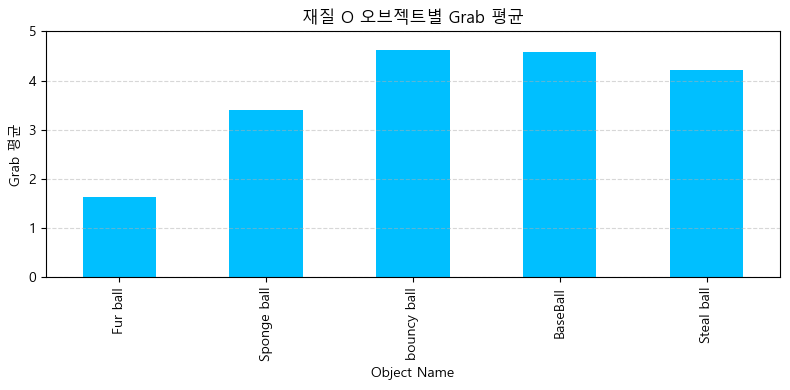

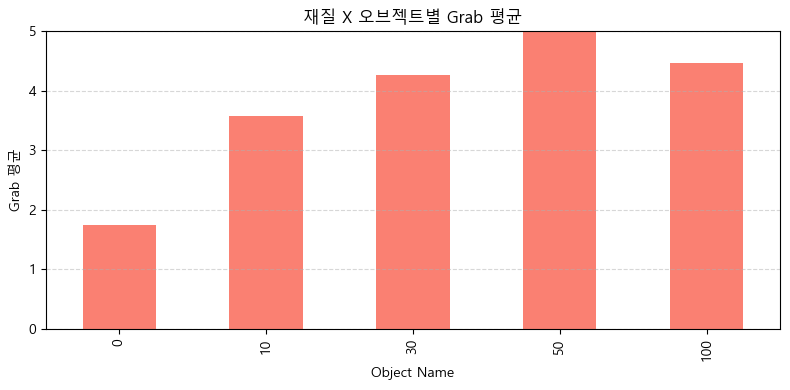

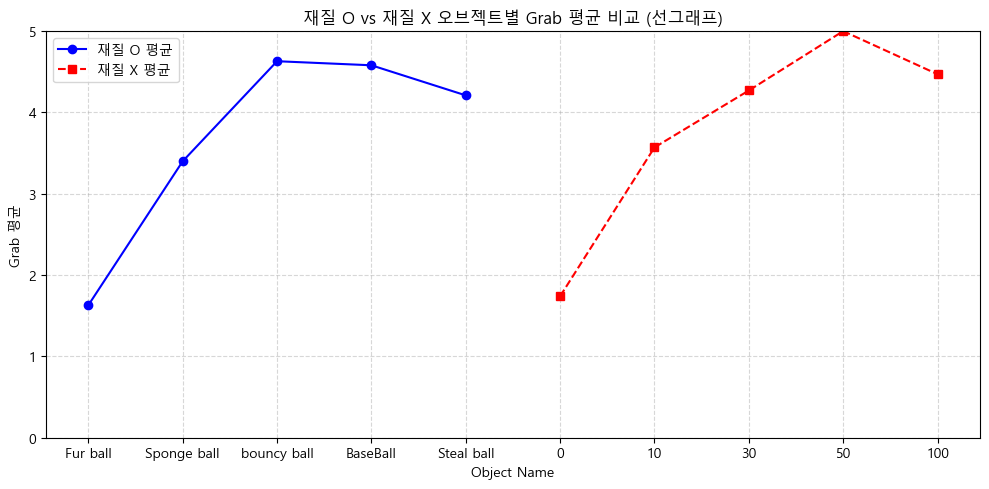

In [14]:
summarize_object_grab_by_type_with_plot("./Full")

In [15]:
def summarize_grab_with_exp_and_test(folder_path):
    english_objects = ["Fur ball", "Sponge ball", "bouncy ball", "BaseBall", "Steal ball"]
    number_objects = ["0", "10", "30", "50", "100"]
    no_exp = ["bosung", "jaehu", "minju", "sarang", "siu", "suyeoun", "wonbin", "jinu", "youngtaek", "suhan"]

    all_data = []

    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            try:
                df = pd.read_csv(file_path)
                df["object_name"] = df["object_name"].astype(str)
                df["object_grab"] = pd.to_numeric(df["object_grab"], errors="coerce")
                df["order_in_session"] = df.groupby("session").cumcount() + 1

                participant = os.path.basename(file).replace("Merge_", "").replace("_full.csv", "")
                df["exp"] = participant not in no_exp

                def classify(obj):
                    if obj in english_objects:
                        return "재질 O"
                    elif obj in number_objects:
                        return "재질 X"
                    else:
                        return "기타"

                df["material_type"] = df["object_name"].apply(classify)
                all_data.append(df)
            except Exception as e:
                print(f"⚠️ 오류 발생: {file} → {e}")

    if not all_data:
        print("📂 분석할 데이터가 없습니다.")
        return

    full_df = pd.concat(all_data, ignore_index=True)

    # ✅ 평균 grab 그래프
    for material, obj_list in [("재질 O", english_objects), ("재질 X", number_objects)]:
        plt.figure(figsize=(10, 5))
        for exp_val, label, color, marker in [(True, "경험자", "blue", "o"), (False, "비경험자", "red", "s")]:
            sub = full_df[(full_df["material_type"] == material) & (full_df["exp"] == exp_val)]
            grab_avg = sub.groupby("object_name")["object_grab"].mean().reindex(obj_list).fillna(0)
            plt.plot(obj_list, grab_avg.values, label=label, marker=marker, linestyle='-')

        plt.title(f"{material} - 오브젝트별 Grab 평균 (경험자 vs 비경험자)")
        plt.xlabel("Object Name")
        plt.ylabel("Grab 평균")
        plt.ylim(0, 6)
        plt.yticks(np.arange(0, 6, 1))
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ✅ 표 생성 및 출력
    grouped_table = full_df.groupby(["exp", "material_type", "object_name"]).agg(
        avg_order=("order_in_session", "mean"),
        avg_grab=("object_grab", "mean"),
        accuracy=("correct", "mean"),
        count=("object_name", "count")
    ).reset_index()

    object_order = english_objects + number_objects
    grouped_table["object_name"] = pd.Categorical(grouped_table["object_name"], categories=object_order, ordered=True)
    grouped_table = grouped_table.sort_values(["exp", "material_type", "object_name"])
    print("\n📊 경험자 vs 비경험자 그룹별 공별 요약 통계:")
    display(grouped_table)

    # ✅ t-test (exp 기준)
    print("\n📌 t-test 결과 (경험자 vs 비경험자):")
    metrics = ["object_grab", "order_in_session", "correct"]
    results = []
    for obj in object_order:
        for metric in metrics:
            sub_df = full_df[full_df["object_name"] == obj]
            if sub_df["exp"].nunique() == 2:
                group1 = sub_df[sub_df["exp"] == True][metric].dropna()
                group0 = sub_df[sub_df["exp"] == False][metric].dropna()
                if len(group1) > 1 and len(group0) > 1:
                    t_stat, p_val = ttest_ind(group1, group0, equal_var=False)
                    results.append([obj, metric, t_stat, p_val])

    result_df = pd.DataFrame(results, columns=["Object", "Metric", "t-statistic", "p-value"])
    display(result_df)

    return grouped_table, result_df

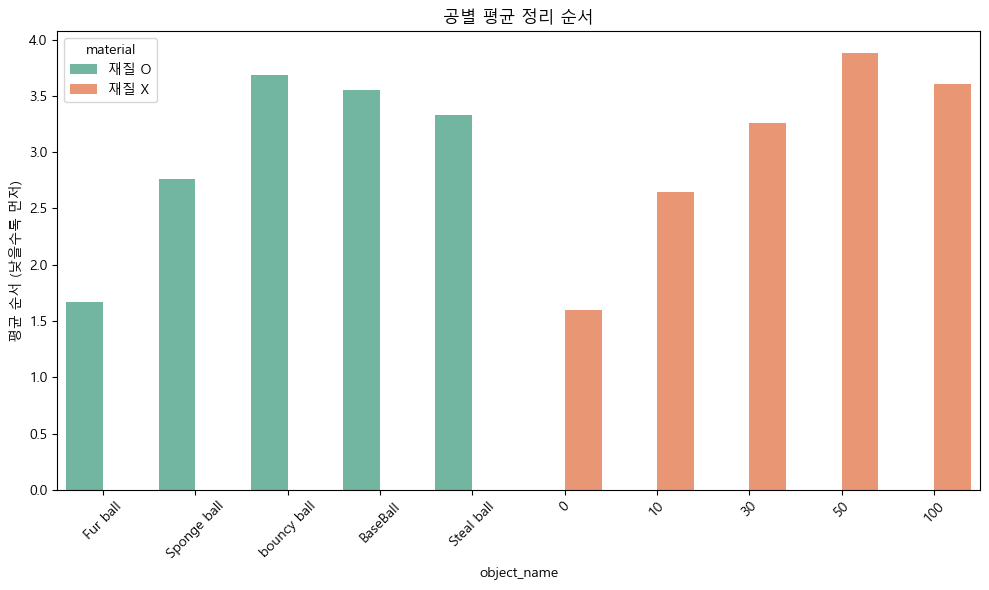

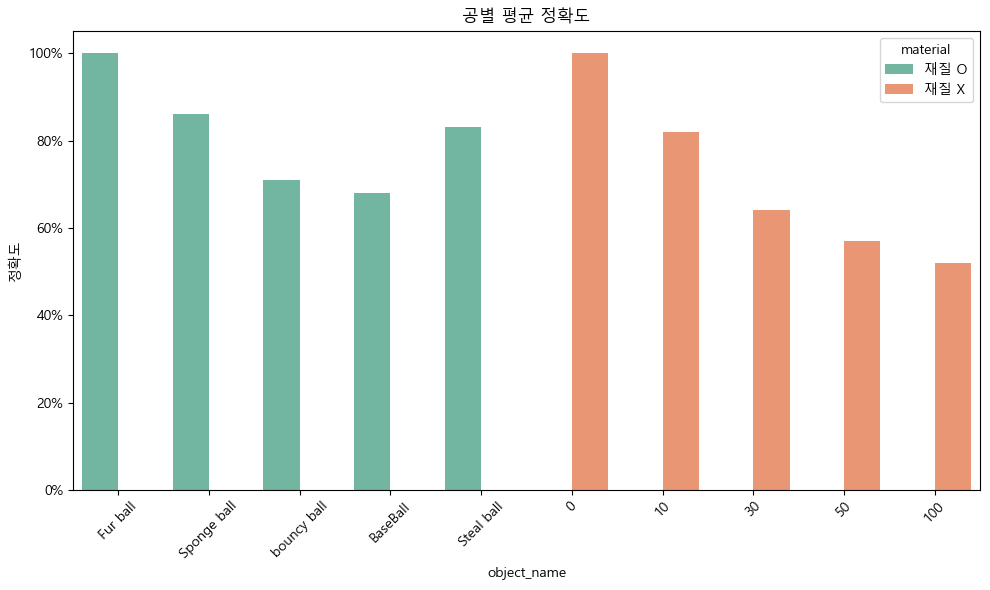

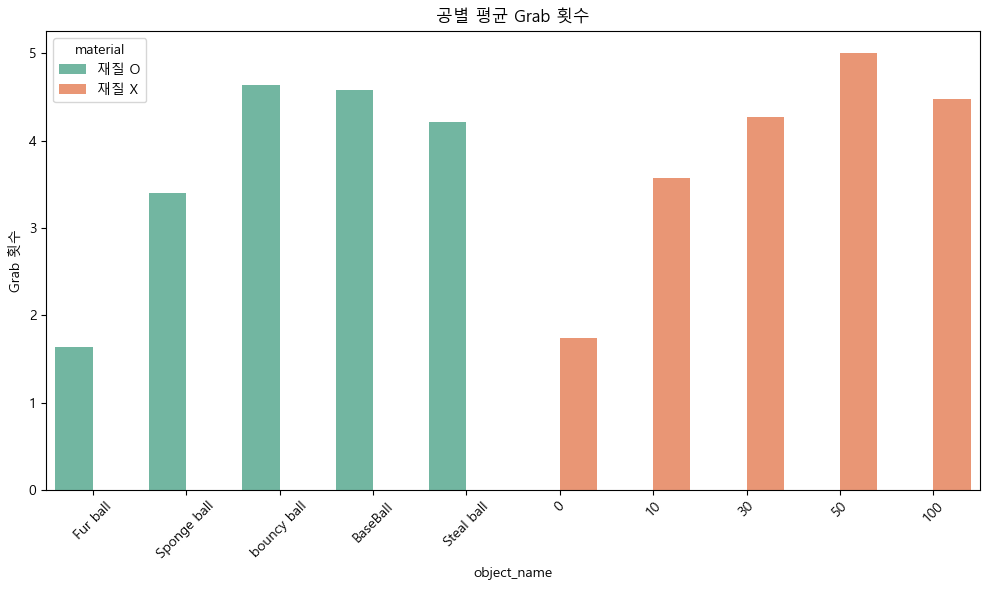

,material,object_name,avg_order,avg_grab,accuracy,count
1,재질 O,Fur ball,1.67,1.63,1.00,100
2,재질 O,Sponge ball,2.76,3.40,0.86,100
4,재질 O,bouncy ball,3.69,4.63,0.71,100
0,재질 O,BaseBall,3.55,4.58,0.68,100
3,재질 O,Steal ball,3.33,4.21,0.83,100
5,재질 X,0,1.60,1.74,1.00,100
6,재질 X,10,2.65,3.57,0.82,100
8,재질 X,30,3.26,4.27,0.64,100
9,재질 X,50,3.88,5.00,0.57,100
7,재질 X,100,3.61,4.47,0.52,100


In [16]:
import os
import pandas as pd
from glob import glob

# 분석용 기준 세트
material_o = {"Fur ball", "Sponge ball", "bouncy ball", "BaseBall", "Steal ball"}
material_x = {"0", "10", "30", "50", "100"}

all_files = glob(os.path.join(output_dir, "*.csv"))

# 🔍 결과 저장 리스트
all_data = []

for file in all_files:
    df = pd.read_csv(file)
    participant = os.path.basename(file).replace(".csv", "")

    # 전처리
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["session", "timestamp"])
    
    # 세션 내 등장 순서 계산
    df["order_in_session"] = df.groupby("session").cumcount() + 1

    # 재질 구분
    df["material"] = df["object_name"].apply(
        lambda x: "재질 O" if str(x) in material_o else ("재질 X" if str(x) in material_x else "Unknown")
    )

    df["participant"] = participant
    all_data.append(df)

# 전체 통합
full_df = pd.concat(all_data, ignore_index=True)

# 🎯 공별 분석
grouped = full_df.groupby(["material", "object_name"]).agg(
    avg_order=("order_in_session", "mean"),
    avg_grab=("object_grab", "mean"),
    accuracy=("correct", "mean"),
    count=("object_name", "count")
).reset_index()

# 결과 출력
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

object_order = [
    "Fur ball", "Sponge ball", "bouncy ball", "BaseBall", "Steal ball",
    "0", "10", "30", "50", "100"
]

grouped["object_name"] = pd.Categorical(grouped["object_name"], categories=object_order, ordered=True)
grouped = grouped.sort_values("object_name")

# 예시 시각화: 등장 순서
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x="object_name", y="avg_order", hue="material", order=object_order, palette="Set2")
plt.title("공별 평균 정리 순서")
plt.ylabel("평균 순서 (낮을수록 먼저)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 예시 시각화: 정확도
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x="object_name", y="accuracy", hue="material", order=object_order, palette="Set2")
plt.title("공별 평균 정확도")
plt.ylabel("정확도")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 예시 시각화: 평균 grab 횟수
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x="object_name", y="avg_grab", hue="material", order=object_order, palette="Set2")
plt.title("공별 평균 Grab 횟수")
plt.ylabel("Grab 횟수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 분석 결과 표도 출력
from IPython.display import display
display(grouped)


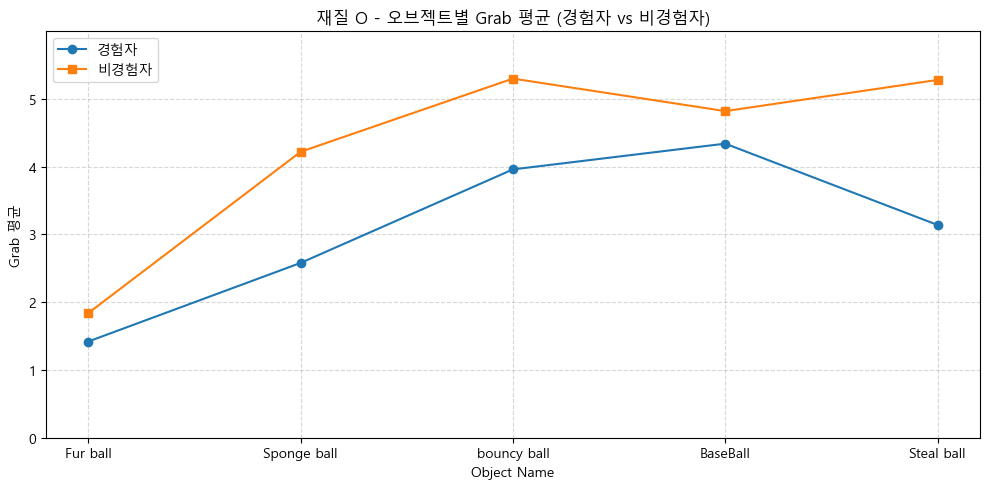

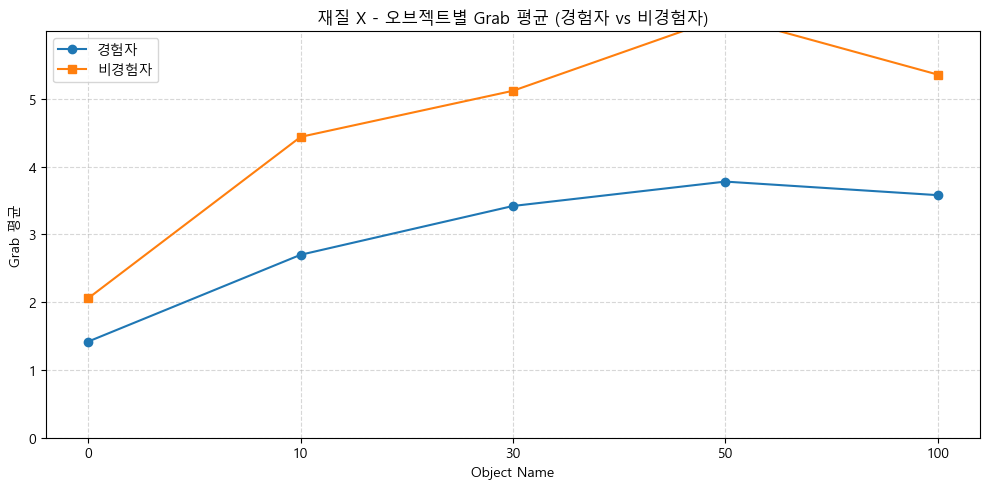


📊 경험자 vs 비경험자 그룹별 공별 요약 통계:


,exp,material_type,object_name,avg_order,avg_grab,accuracy,count
1,False,재질 O,Fur ball,1.36,1.84,1.00,50
2,False,재질 O,Sponge ball,3.12,4.22,0.74,50
4,False,재질 O,bouncy ball,3.76,5.30,0.54,50
0,False,재질 O,BaseBall,3.50,4.82,0.48,50
3,False,재질 O,Steal ball,3.26,5.28,0.68,50
5,False,재질 X,0,1.54,2.06,1.00,50
6,False,재질 X,10,2.68,4.44,0.70,50
8,False,재질 X,30,3.34,5.12,0.42,50
9,False,재질 X,50,3.86,6.22,0.40,50
7,False,재질 X,100,3.58,5.36,0.28,50



📌 t-test 결과 (경험자 vs 비경험자):


,Object,Metric,t-statistic,p-value
0,Fur ball,object_grab,-2.504510,1.406284e-02
1,Fur ball,order_in_session,2.728535,7.714132e-03
2,Fur ball,correct,NaN,NaN
3,Sponge ball,object_grab,-2.666510,8.973457e-03
4,Sponge ball,order_in_session,-2.878543,4.905207e-03
5,Sponge ball,correct,3.648727,5.605489e-04
6,bouncy ball,object_grab,-1.676915,9.675900e-02
7,bouncy ball,order_in_session,-0.658029,5.120968e-01
8,bouncy ball,correct,4.000141,1.353836e-04
9,BaseBall,object_grab,-0.649866,5.173943e-01


(      exp material_type  object_name  avg_order  avg_grab  accuracy  count
 1   False          재질 O     Fur ball       1.36      1.84      1.00     50
 2   False          재질 O  Sponge ball       3.12      4.22      0.74     50
 4   False          재질 O  bouncy ball       3.76      5.30      0.54     50
 0   False          재질 O     BaseBall       3.50      4.82      0.48     50
 3   False          재질 O   Steal ball       3.26      5.28      0.68     50
 5   False          재질 X            0       1.54      2.06      1.00     50
 6   False          재질 X           10       2.68      4.44      0.70     50
 8   False          재질 X           30       3.34      5.12      0.42     50
 9   False          재질 X           50       3.86      6.22      0.40     50
 7   False          재질 X          100       3.58      5.36      0.28     50
 11   True          재질 O     Fur ball       1.98      1.42      1.00     50
 12   True          재질 O  Sponge ball       2.40      2.58      0.98     50
 14   True  

In [17]:
summarize_grab_with_exp_and_test("./Full")

📌 Grab ↔ 정확도 상관: Spearman r = -0.644, p = 0.0000
📌 순서 ↔ 정확도 상관: Spearman r = -0.503, p = 0.0000

📌 ANOVA 결과 (오브젝트별 정확도 차이): F = 6.9096, p = 0.0000


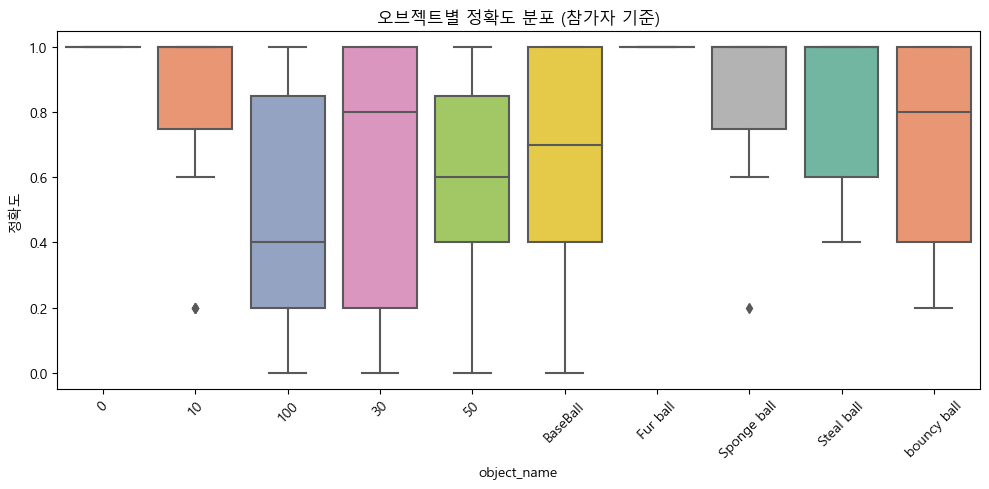

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, f_oneway

# ▶️ 참가자별 기준으로 데이터 준비
agg_df = full_df.groupby(["participant", "object_name"]).agg(
    total_grab=("object_grab", "sum"),
    avg_order=("order_in_session", "mean"),
    accuracy=("correct", "mean")
).reset_index()

# 🎯 상관관계 분석
corr_grab, p_grab = spearmanr(agg_df["total_grab"], agg_df["accuracy"])
corr_order, p_order = spearmanr(agg_df["avg_order"], agg_df["accuracy"])

print(f"📌 Grab ↔ 정확도 상관: Spearman r = {corr_grab:.3f}, p = {p_grab:.4f}")
print(f"📌 순서 ↔ 정확도 상관: Spearman r = {corr_order:.3f}, p = {p_order:.4f}")

# 🧪 ANOVA: 오브젝트별 정확도 차이
anova_data = [group["accuracy"].values for _, group in agg_df.groupby("object_name")]
anova_result = f_oneway(*anova_data)

print(f"\n📌 ANOVA 결과 (오브젝트별 정확도 차이): F = {anova_result.statistic:.4f}, p = {anova_result.pvalue:.4f}")

# 📊 오브젝트별 정확도 시각화
plt.figure(figsize=(10, 5))
sns.boxplot(data=agg_df, x="object_name", y="accuracy", palette="Set2")
plt.title("오브젝트별 정확도 분포 (참가자 기준)")
plt.ylabel("정확도")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
import pandas as pd
from scipy.stats import shapiro
from IPython.display import display

# 참가자별 집계: 정확도, Grab, Duration, 정리 순서
grouped = full_df.groupby(["participant", "material", "exp"]).agg(
    정확도=("correct", "mean"),
    Grab=("object_grab", "sum"),
    Duration=("session_duration", "mean"),
    정리순서=("order_in_session", "mean")
).reset_index()

# 정규성 검정 대상 변수들
variables = ["정확도", "Grab", "Duration", "정리순서"]
normality_results = []

for var in variables:
    for mat in ["재질 O", "재질 X"]:
        for exp in [True, False]:
            subset = grouped[(grouped["material"] == mat) & (grouped["exp"] == exp)][var].dropna()
            if len(subset) >= 3:
                stat, p = shapiro(subset)
                normality_results.append({
                    "변수": var,
                    "조건": f"{mat}, {'경험자' if exp else '비경험자'}",
                    "샘플수": len(subset),
                    "Shapiro-W": round(stat, 4),
                    "p-value": round(p, 4),
                    "정규성": "만족" if p > 0.05 else "위반"
                })

# 결과 출력
normal_df = pd.DataFrame(normality_results)
print("✅ 정규성 검정 결과 (정리순서 포함):")
display(normal_df)


✅ 정규성 검정 결과 (정리순서 포함):


c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\scipy\stats\morestats.py:1757: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "


,변수,조건,샘플수,Shapiro-W,p-value,정규성
0,정확도,"재질 O, 경험자",10,0.6057,0.0001,위반
1,정확도,"재질 O, 비경험자",10,0.9136,0.3070,만족
2,정확도,"재질 X, 경험자",10,0.6479,0.0002,위반
3,정확도,"재질 X, 비경험자",10,0.9347,0.4953,만족
4,Grab,"재질 O, 경험자",10,0.8468,0.0532,만족
5,Grab,"재질 O, 비경험자",10,0.9188,0.3467,만족
6,Grab,"재질 X, 경험자",10,0.8744,0.1124,만족
7,Grab,"재질 X, 비경험자",10,0.8694,0.0983,만족
8,Duration,"재질 O, 경험자",10,0.9364,0.5136,만족
9,Duration,"재질 O, 비경험자",10,0.9316,0.4638,만족


In [20]:
full_df.head()

,timestamp,object_name,object_grab,total_grab,session,session_duration,zone,Timestamp,SourceFile,expected_zone,correct,exp,order_in_session,material,participant
0,2025-03-25 19:09:21,Sponge ball,4,12,1,41.0,1,2025-03-25 19:09:21,20250325_190933_bosung_zone_log1.csv,1,True,False,1,재질 O,Merge_bosung_full
1,2025-03-25 19:09:22,Fur ball,4,13,1,41.0,0,2025-03-25 19:09:23,20250325_190933_bosung_zone_log1.csv,0,True,False,2,재질 O,Merge_bosung_full
2,2025-03-25 19:09:24,BaseBall,3,14,1,41.0,2,2025-03-25 19:09:25,20250325_190933_bosung_zone_log1.csv,3,False,False,3,재질 O,Merge_bosung_full
3,2025-03-25 19:09:27,bouncy ball,4,16,1,41.0,3,2025-03-25 19:09:28,20250325_190933_bosung_zone_log1.csv,2,False,False,4,재질 O,Merge_bosung_full
4,2025-03-25 19:09:29,Steal ball,3,18,1,41.0,4,2025-03-25 19:09:30,20250325_190933_bosung_zone_log1.csv,4,True,False,5,재질 O,Merge_bosung_full


In [25]:
import pandas as pd
from glob import glob
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, pearsonr, spearmanr, ttest_rel, wilcoxon

# 요약 통계 계산
summary = full_df.groupby(["participant", "material", "exp"]).agg(
    accuracy=("correct", "mean"),
    avg_grab=("object_grab", "mean"),
    avg_order=("order_in_session", "mean"),
    session_duration=("session_duration", "mean")  # 🔥 추가됨
).reset_index()

variables = ["accuracy", "avg_grab", "session_duration"]

# 정규성 검사
normality_results = []


for var in variables:
    for mat in ["재질 O", "재질 X"]:
        subset = summary[(summary["material"] == mat) & (summary["exp"] == exp)][var].dropna()
        if len(subset) >= 3 and subset.nunique() > 1:
            stat, p = shapiro(subset)
            normality_results.append({
                "변수": var,
                "조건": f"{mat}, {'경험자' if exp else '비경험자'}",
                "샘플수": len(subset),
                "Shapiro-W": stat,
                "p-value": p,
                "정규성": "만족" if p > 0.05 else "위반"
            })
        elif subset.nunique() <= 1:
            normality_results.append({
                "변수": var,
                "조건": f"{mat}, {'경험자' if exp else '비경험자'}",
                "샘플수": len(subset),
                "Shapiro-W": None,
                "p-value": None,
                "정규성": "값이 모두 같음 (검정 불가)"
            })


normality_df = pd.DataFrame(normality_results)

for var in variables:
    for mat in ["재질 O", "재질 X"]:
        for exp in [True, False]:
            subset = summary[(summary["material"] == mat) & (summary["exp"] == exp)][var].dropna()
            if len(subset) >= 3 and subset.nunique() > 1:
                stat, p = shapiro(subset)
                normality_results.append({
                    "변수": var,
                    "조건": f"{mat}, {'경험자' if exp else '비경험자'}",
                    "샘플수": len(subset),
                    "Shapiro-W": stat,
                    "p-value": p,
                    "정규성": "만족" if p > 0.05 else "위반"
                })
            elif subset.nunique() <= 1:
                normality_results.append({
                    "변수": var,
                    "조건": f"{mat}, {'경험자' if exp else '비경험자'}",
                    "샘플수": len(subset),
                    "Shapiro-W": None,
                    "p-value": None,
                    "정규성": "값이 모두 같음 (검정 불가)"
                })

normality_df = pd.DataFrame(normality_results)

# Between-Subject 통계 검정 (경험자 vs 비경험자)
test_results = []
for var in variables:
    for mat in ["재질 O", "재질 X"]:
        data_exp = summary[(summary["material"] == mat) & (summary["exp"] == True)][var]
        data_non = summary[(summary["material"] == mat) & (summary["exp"] == False)][var]
        if len(data_exp) >= 3 and len(data_non) >= 3:
            p_normal_exp = shapiro(data_exp)[1]
            p_normal_non = shapiro(data_non)[1]
            if p_normal_exp > 0.05 and p_normal_non > 0.05:
                stat, p = ttest_ind(data_exp, data_non)
                test_type = "독립표본 t-검정"
            else:
                stat, p = mannwhitneyu(data_exp, data_non)
                test_type = "Mann-Whitney U"
            test_results.append({
                "비교유형": "Between",
                "변수": var,
                "재질": mat,
                "검정방법": test_type,
                "샘플수": min(len(data_exp), len(data_non)),
                "통계량": stat,
                "p-value": p
            })

test_results_df = pd.DataFrame(test_results)

# Within-Subject 통계 검정 (같은 참가자 내 재질 O vs X)
within_results = []
for var in variables:
    pivot_df = summary.pivot(index="participant", columns="material", values=var).dropna()
    if "재질 O" in pivot_df.columns and "재질 X" in pivot_df.columns:
        data_o = pivot_df["재질 O"]
        data_x = pivot_df["재질 X"]
        if len(data_o) >= 3:
            p_normal_o = shapiro(data_o)[1]
            p_normal_x = shapiro(data_x)[1]
            if p_normal_o > 0.05 and p_normal_x > 0.05:
                stat, p = ttest_rel(data_o, data_x)
                test_type = "대응표본 t-검정"
            else:
                stat, p = wilcoxon(data_o, data_x)
                test_type = "Wilcoxon signed-rank"
            within_results.append({
                "비교유형": "Within",
                "변수": var,
                "재질": "재질 O vs 재질 X",
                "검정방법": test_type,
                "샘플수": len(data_o),
                "통계량": stat,
                "p-value": p
            })


within_results_df = pd.DataFrame(within_results)

# 전체 통계 검정 결과 통합
combined_results_df = pd.concat([test_results_df, within_results_df], ignore_index=True)

print("📊 정규성 검정 결과:")
display(normality_df)
print("\n📊 통계 검정 결과:")
display(combined_results_df)

correlation_df = summary.groupby("participant")[["accuracy", "avg_grab", "session_duration"]].mean()
display(correlation_df)

# 상관 분석 결과 저장 리스트
correlation_results = []

# 모든 변수 쌍 조합
pairs = [("accuracy", "avg_grab"), ("accuracy", "session_duration"), ("avg_grab", "session_duration")]

# 각 쌍마다 상관계수 계산
for x, y in pairs:
    x_p = shapiro(correlation_df[x])[1]
    y_p = shapiro(correlation_df[y])[1]

    if x_p > 0.05 and y_p > 0.05:
        corr, pval = pearsonr(correlation_df[x], correlation_df[y])
        method = "Pearson"
    else:
        corr, pval = spearmanr(correlation_df[x], correlation_df[y])
        method = "Spearman"

    correlation_results.append({
        "변수1": x,
        "변수2": y,
        "검정방법": method,
        "상관계수": round(corr, 3),
        "p-value": round(pval, 4)
    })

# 결과 DataFrame
correlation_df_result = pd.DataFrame(correlation_results)
display(correlation_df_result)

📊 정규성 검정 결과:


c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\scipy\stats\morestats.py:3141: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,변수,조건,샘플수,Shapiro-W,p-value,정규성
0,accuracy,"재질 O, 비경험자",10,0.913648,0.307000,만족
1,accuracy,"재질 X, 비경험자",10,0.934662,0.495283,만족
2,avg_grab,"재질 O, 비경험자",10,0.918759,0.346718,만족
3,avg_grab,"재질 X, 비경험자",10,0.869363,0.098271,만족
4,session_duration,"재질 O, 비경험자",10,0.931601,0.463821,만족
5,session_duration,"재질 X, 비경험자",10,0.929607,0.444038,만족
6,accuracy,"재질 O, 경험자",10,0.605705,0.000065,위반
7,accuracy,"재질 O, 비경험자",10,0.913648,0.307000,만족
8,accuracy,"재질 X, 경험자",10,0.647920,0.000207,위반
9,accuracy,"재질 X, 비경험자",10,0.934662,0.495283,만족



📊 통계 검정 결과:


,비교유형,변수,재질,검정방법,샘플수,통계량,p-value
0,Between,accuracy,재질 O,Mann-Whitney U,10,88.500000,0.002930
1,Between,accuracy,재질 X,Mann-Whitney U,10,85.500000,0.007517
2,Between,avg_grab,재질 O,독립표본 t-검정,10,-1.627154,0.121082
3,Between,avg_grab,재질 X,독립표본 t-검정,10,-2.744095,0.013339
4,Between,session_duration,재질 O,독립표본 t-검정,10,-2.069913,0.053123
5,Between,session_duration,재질 X,독립표본 t-검정,10,-3.051940,0.006863
6,Within,accuracy,재질 O vs 재질 X,Wilcoxon signed-rank,20,8.000000,0.002994
7,Within,avg_grab,재질 O vs 재질 X,Wilcoxon signed-rank,20,77.000000,0.311794
8,Within,session_duration,재질 O vs 재질 X,대응표본 t-검정,20,-0.774802,0.447992


,accuracy,avg_grab,session_duration
participant,,,
Merge_bosung_full,0.60,6.28,64.6
Merge_dohoon_full,1.00,1.82,19.8
Merge_euncha_full,0.54,5.74,51.1
Merge_hyunwook_full,1.00,2.16,19.8
Merge_jaeho_full,0.96,3.54,48.3
Merge_jaehu_full,0.88,2.56,64.5
Merge_jinu_full,0.52,5.62,58.9
Merge_jiyoung_full,0.96,2.94,23.9
Merge_minho_full,0.96,2.16,55.4


,변수1,변수2,검정방법,상관계수,p-value
0,accuracy,avg_grab,Spearman,-0.642,0.0023
1,accuracy,session_duration,Spearman,-0.629,0.0030
2,avg_grab,session_duration,Spearman,0.729,0.0003


In [28]:
from scipy.stats import shapiro, ttest_rel, wilcoxon, pearsonr, spearmanr
import pandas as pd

# 1. 참가자별 요약 통계 (경험자 exp 없이)
summary = full_df.groupby(["participant", "material"]).agg(
    accuracy=("correct", "mean"),
    avg_grab=("object_grab", "mean"),
    avg_order=("order_in_session", "mean"),
    session_duration=("session_duration", "mean")
).reset_index()

variables = ["accuracy", "avg_grab", "session_duration"]

# 2. 정규성 검정
normality_results = []
for var in variables:
    for mat in ["재질 O", "재질 X"]:
        subset = summary[summary["material"] == mat][var].dropna()
        if len(subset) >= 3:
            if subset.nunique() > 1:
                stat, p = shapiro(subset)
                normality_results.append({
                    "변수": var,
                    "재질": mat,
                    "샘플수": len(subset),
                    "Shapiro-W": stat,
                    "p-value": p,
                    "정규성": "만족" if p > 0.05 else "위반"
                })
            else:
                normality_results.append({
                    "변수": var,
                    "재질": mat,
                    "샘플수": len(subset),
                    "Shapiro-W": None,
                    "p-value": None,
                    "정규성": "값이 모두 같음 (검정 불가)"
                })

normality_df = pd.DataFrame(normality_results)

# 3. 재질 O vs X (Within-Subject 통계 검정)
within_results = []
for var in variables:
    pivot_df = summary.pivot(index="participant", columns="material", values=var).dropna()
    if "재질 O" in pivot_df.columns and "재질 X" in pivot_df.columns:
        data_o = pivot_df["재질 O"]
        data_x = pivot_df["재질 X"]
        if len(data_o) >= 3:
            p_o = shapiro(data_o)[1]
            p_x = shapiro(data_x)[1]
            if p_o > 0.05 and p_x > 0.05:
                stat, p = ttest_rel(data_o, data_x)
                test_type = "대응표본 t-검정"
            else:
                stat, p = wilcoxon(data_o, data_x)
                test_type = "Wilcoxon signed-rank"
            within_results.append({
                "변수": var,
                "검정방법": test_type,
                "샘플수": len(data_o),
                "통계량": stat,
                "p-value": p
            })

within_results_df = pd.DataFrame(within_results)

# 4. 변수 간 상관분석 (participant 평균 기준)
correlation_summary = summary.groupby("participant")[variables].mean()
correlation_results = []
for x, y in [("accuracy", "avg_grab"), ("accuracy", "session_duration"), ("avg_grab", "session_duration")]:
    x_p = shapiro(correlation_summary[x])[1]
    y_p = shapiro(correlation_summary[y])[1]
    if x_p > 0.05 and y_p > 0.05:
        corr, pval = pearsonr(correlation_summary[x], correlation_summary[y])
        method = "Pearson"
    else:
        corr, pval = spearmanr(correlation_summary[x], correlation_summary[y])
        method = "Spearman"
    correlation_results.append({
        "변수1": x,
        "변수2": y,
        "검정방법": method,
        "상관계수": round(corr, 3),
        "p-value": round(pval, 4)
    })

correlation_df = pd.DataFrame(correlation_results)

# 결과 확인
display(normality_df)
display(within_results_df)
display(correlation_df)


c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\scipy\stats\morestats.py:3141: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,변수,재질,샘플수,Shapiro-W,p-value,정규성
0,accuracy,재질 O,20,0.842557,0.004010,위반
1,accuracy,재질 X,20,0.902932,0.046818,위반
2,avg_grab,재질 O,20,0.901071,0.043192,위반
3,avg_grab,재질 X,20,0.878050,0.016323,위반
4,session_duration,재질 O,20,0.966245,0.674451,만족
5,session_duration,재질 X,20,0.937212,0.212273,만족


,변수,검정방법,샘플수,통계량,p-value
0,accuracy,Wilcoxon signed-rank,20,8.000000,0.002994
1,avg_grab,Wilcoxon signed-rank,20,77.000000,0.311794
2,session_duration,대응표본 t-검정,20,-0.774802,0.447992


,변수1,변수2,검정방법,상관계수,p-value
0,accuracy,avg_grab,Spearman,-0.642,0.0023
1,accuracy,session_duration,Spearman,-0.629,0.0030
2,avg_grab,session_duration,Spearman,0.729,0.0003


In [ ]:
from scipy.stats import shapiro, ttest_rel, wilcoxon, pearsonr, spearmanr
import pandas as pd

# 1. 참가자별 요약 통계 (경험자 exp 없이)
summary = full_df.groupby(["participant", "material"]).agg(
    accuracy=("correct", "mean"),
    avg_grab=("object_grab", "mean"),
    avg_order=("order_in_session", "mean"),
    session_duration=("session_duration", "mean")
).reset_index()

variables = ["accuracy", "avg_grab", "session_duration"]

# 2. 정규성 검정
normality_results = []
for var in variables:
    for mat in ["재질 O", "재질 X"]:
        subset = summary[summary["material"] == mat][var].dropna()
        if len(subset) >= 3:
            if subset.nunique() > 1:
                stat, p = shapiro(subset)
                normality_results.append({
                    "변수": var,
                    "재질": mat,
                    "샘플수": len(subset),
                    "Shapiro-W": stat,
                    "p-value": p,
                    "정규성": "만족" if p > 0.05 else "위반"
                })
            else:
                normality_results.append({
                    "변수": var,
                    "재질": mat,
                    "샘플수": len(subset),
                    "Shapiro-W": None,
                    "p-value": None,
                    "정규성": "값이 모두 같음 (검정 불가)"
                })

normality_df = pd.DataFrame(normality_results)

# 3. 재질 O vs X (Within-Subject 통계 검정)
within_results = []
for var in variables:
    pivot_df = summary.pivot(index="participant", columns="material", values=var).dropna()
    if "재질 O" in pivot_df.columns and "재질 X" in pivot_df.columns:
        data_o = pivot_df["재질 O"]
        data_x = pivot_df["재질 X"]
        if len(data_o) >= 3:
            p_o = shapiro(data_o)[1]
            p_x = shapiro(data_x)[1]
            if p_o > 0.05 and p_x > 0.05:
                stat, p = ttest_rel(data_o, data_x)
                test_type = "대응표본 t-검정"
            else:
                stat, p = wilcoxon(data_o, data_x)
                test_type = "Wilcoxon signed-rank"
            within_results.append({
                "변수": var,
                "검정방법": test_type,
                "샘플수": len(data_o),
                "통계량": stat,
                "p-value": p
            })

within_results_df = pd.DataFrame(within_results)

# 4. 변수 간 상관분석 (participant 평균 기준)
correlation_summary = summary.groupby("participant")[variables].mean()
correlation_results = []
for x, y in [("accuracy", "avg_grab"), ("accuracy", "session_duration"), ("avg_grab", "session_duration")]:
    x_p = shapiro(correlation_summary[x])[1]
    y_p = shapiro(correlation_summary[y])[1]
    if x_p > 0.05 and y_p > 0.05:
        corr, pval = pearsonr(correlation_summary[x], correlation_summary[y])
        method = "Pearson"
    else:
        corr, pval = spearmanr(correlation_summary[x], correlation_summary[y])
        method = "Spearman"
    correlation_results.append({
        "변수1": x,
        "변수2": y,
        "검정방법": method,
        "상관계수": round(corr, 3),
        "p-value": round(pval, 4)
    })

correlation_df = pd.DataFrame(correlation_results)

# 결과 확인
display(normality_df)
display(within_results_df)
display(correlation_df)


c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\scipy\stats\morestats.py:3141: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,변수,재질,샘플수,Shapiro-W,p-value,정규성
0,accuracy,재질 O,20,0.842557,0.004010,위반
1,accuracy,재질 X,20,0.902932,0.046818,위반
2,avg_grab,재질 O,20,0.901071,0.043192,위반
3,avg_grab,재질 X,20,0.878050,0.016323,위반
4,session_duration,재질 O,20,0.966245,0.674451,만족
5,session_duration,재질 X,20,0.937212,0.212273,만족


,변수,검정방법,샘플수,통계량,p-value
0,accuracy,Wilcoxon signed-rank,20,8.000000,0.002994
1,avg_grab,Wilcoxon signed-rank,20,77.000000,0.311794
2,session_duration,대응표본 t-검정,20,-0.774802,0.447992


,변수1,변수2,검정방법,상관계수,p-value
0,accuracy,avg_grab,Spearman,-0.642,0.0023
1,accuracy,session_duration,Spearman,-0.629,0.0030
2,avg_grab,session_duration,Spearman,0.729,0.0003


In [ ]:
group_means = summary.groupby(["material", "exp"])["avg_grab"].mean().reset_index()
group_means["exp"] = group_means["exp"].map({True: "경험자", False: "비경험자"})
group_means = group_means[["material", "exp", "avg_grab"]]
display(group_means)

,material,exp,avg_grab
0,재질 O,비경험자,4.292
1,재질 O,경험자,3.088
2,재질 X,비경험자,4.640
3,재질 X,경험자,2.980


 accuracy가 높을수록 avg_grab은 낮아지는 경향

In [ ]:
summary

,participant,material,exp,accuracy,avg_grab,avg_order
0,Merge_bosung_full,재질 O,False,0.56,6.88,3.0
1,Merge_bosung_full,재질 X,False,0.64,5.68,3.0
2,Merge_dohoon_full,재질 O,True,1.00,1.72,3.0
3,Merge_dohoon_full,재질 X,True,1.00,1.92,3.0
4,Merge_euncha_full,재질 O,True,0.76,6.48,3.0
5,Merge_euncha_full,재질 X,True,0.32,5.00,3.0
6,Merge_hyunwook_full,재질 O,True,1.00,1.72,3.0
7,Merge_hyunwook_full,재질 X,True,1.00,2.60,3.0
8,Merge_jaeho_full,재질 O,True,1.00,4.12,3.0
9,Merge_jaeho_full,재질 X,True,0.92,2.96,3.0


,object_name,accuracy,avg_grab,avg_order,count,material
0,0,1.00,1.74,1.60,100,재질 X
1,10,0.82,3.57,2.65,100,재질 X
2,100,0.52,4.47,3.61,100,재질 X
3,30,0.64,4.27,3.26,100,재질 X
4,50,0.57,5.00,3.88,100,재질 X
5,BaseBall,0.68,4.58,3.55,100,재질 O
6,Fur ball,1.00,1.63,1.67,100,재질 O
7,Sponge ball,0.86,3.40,2.76,100,재질 O
8,Steal ball,0.83,4.21,3.33,100,재질 O
9,bouncy ball,0.71,4.63,3.69,100,재질 O


c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\ipykernel_launcher.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



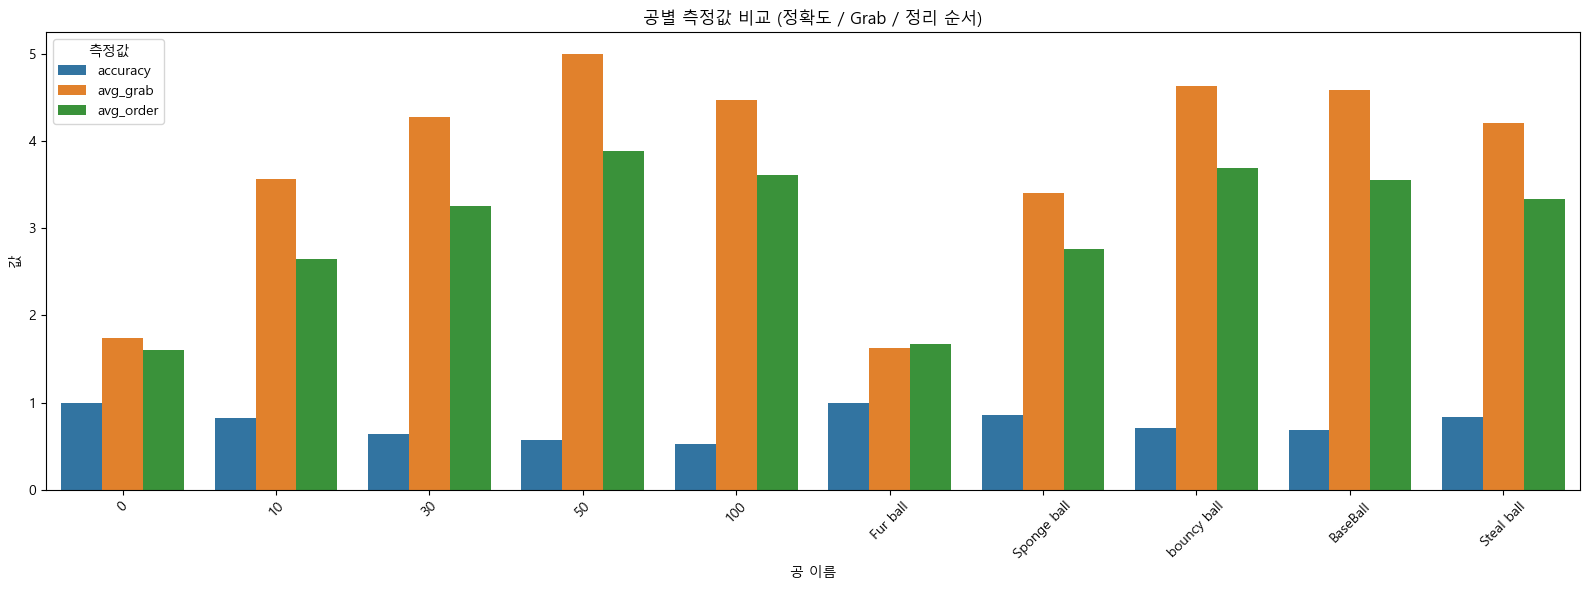

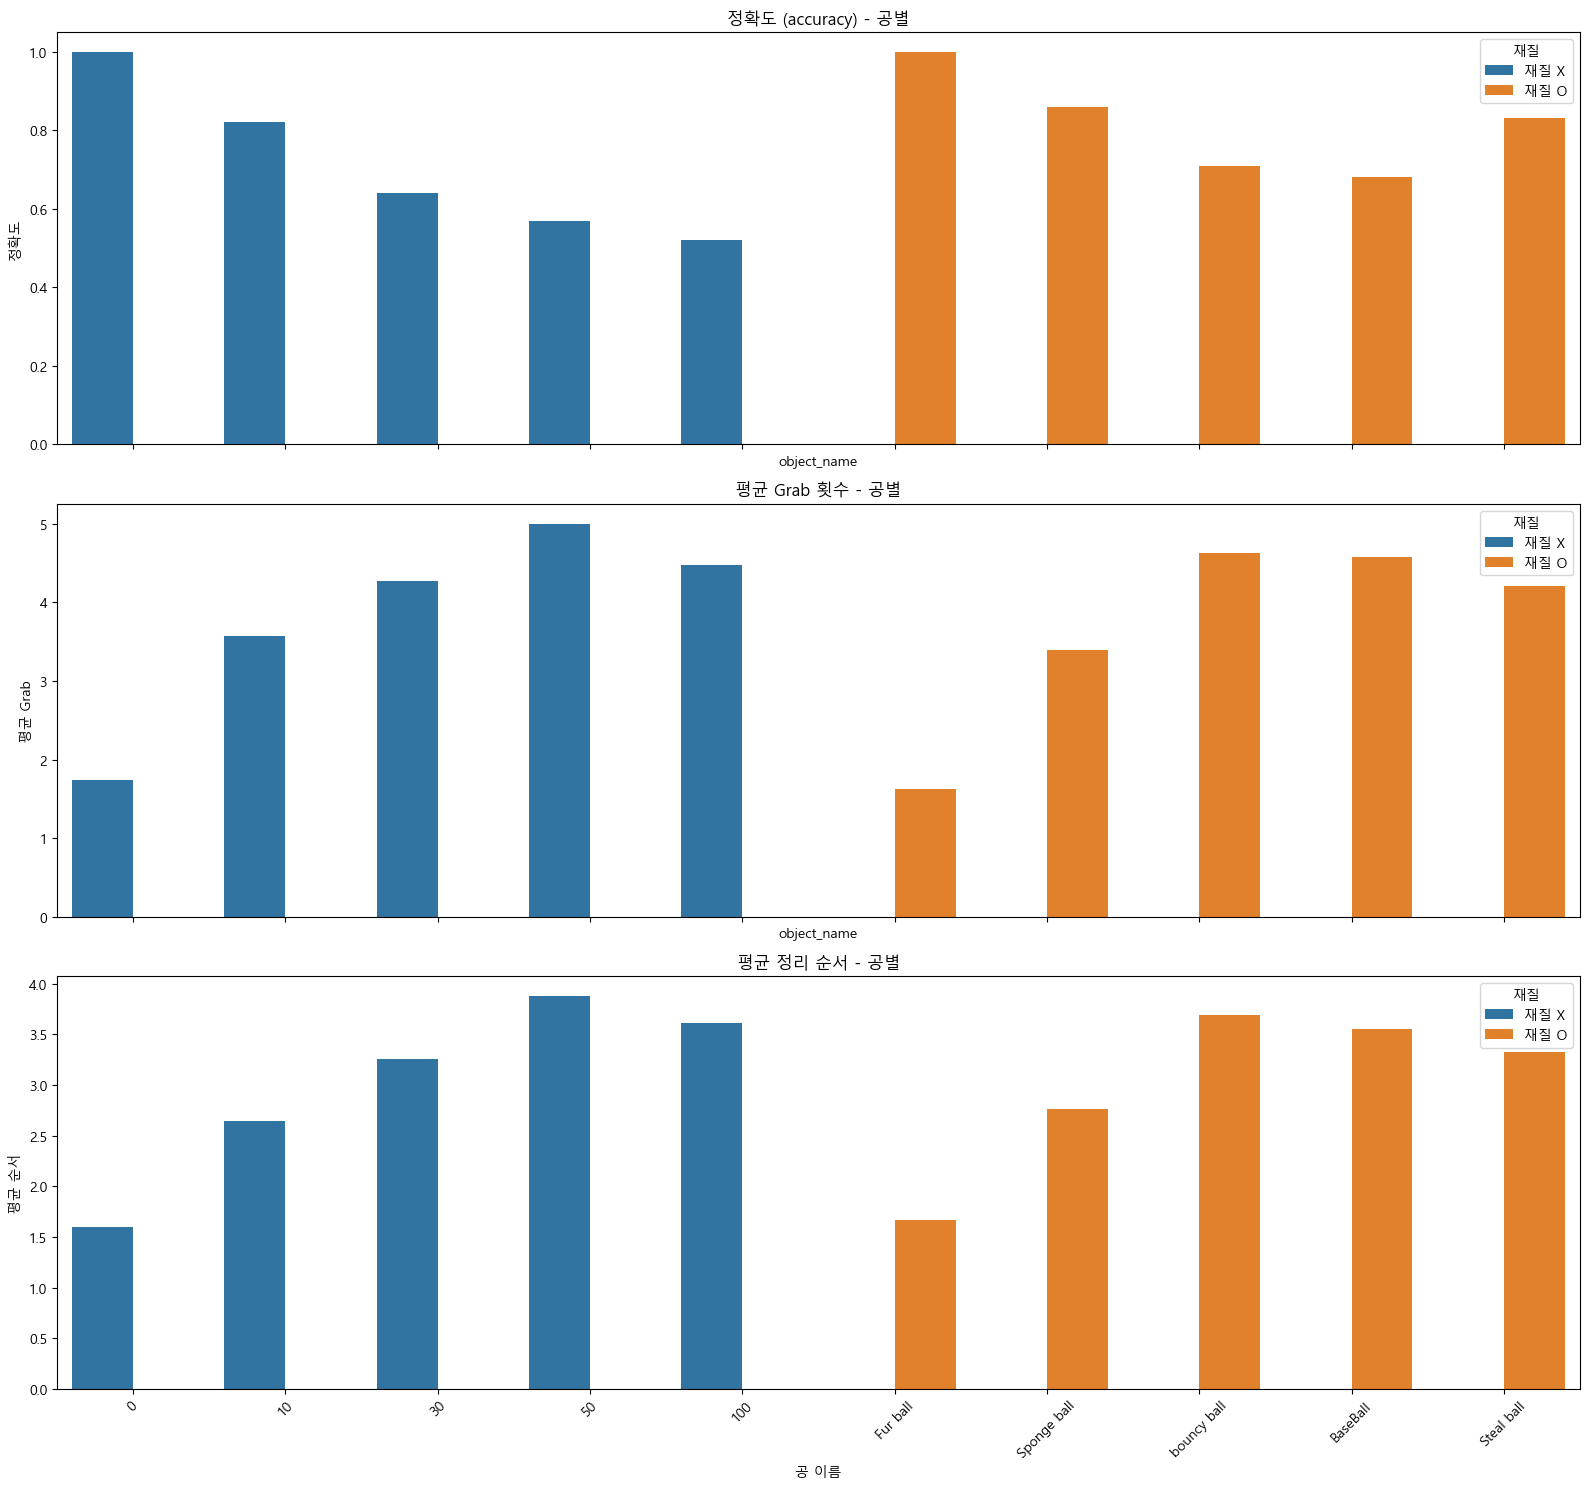

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 공별 요약 통계 계산
object_summary = full_df.groupby("object_name").agg(
    accuracy=("correct", "mean"),
    avg_grab=("object_grab", "mean"),
    avg_order=("order_in_session", "mean"),
    count=("object_name", "count"),
    material=("material", "first")
).reset_index()

display(object_summary)

# 2. 사용자 지정 공 순서 (왼쪽: 재질 X, 오른쪽: 재질 O)
object_order = ["0", "10", "30", "50", "100", "Fur ball", "Sponge ball", "bouncy ball", "BaseBall", "Steal ball"]
object_summary["object_name"] = pd.Categorical(object_summary["object_name"], categories=object_order, ordered=True)
object_summary = object_summary.sort_values("object_name")

# 3. Long-format 변환 (하나의 plot에 전체 값 비교용)
melted = object_summary.melt(
    id_vars=["object_name", "material"],
    value_vars=["accuracy", "avg_grab", "avg_order"],
    var_name="측정값",
    value_name="값"
)

# 4-1. 📊 하나의 plot에 모든 측정값을 겹쳐서 표현
plt.figure(figsize=(16, 6))
sns.barplot(data=melted, x="object_name", y="값", hue="측정값", ci=None)
plt.title("공별 측정값 비교 (정확도 / Grab / 정리 순서)")
plt.xlabel("공 이름")
plt.ylabel("값")
plt.xticks(rotation=45)
plt.legend(title="측정값")
plt.tight_layout()
plt.show()

# 4-2. 📊 변수별로 개별 plot 생성 (정렬 및 재질 hue 포함)
fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)

sns.barplot(data=object_summary, x="object_name", y="accuracy", hue="material", ax=axes[0])
axes[0].set_title("정확도 (accuracy) - 공별")
axes[0].set_ylabel("정확도")

sns.barplot(data=object_summary, x="object_name", y="avg_grab", hue="material", ax=axes[1])
axes[1].set_title("평균 Grab 횟수 - 공별")
axes[1].set_ylabel("평균 Grab")

sns.barplot(data=object_summary, x="object_name", y="avg_order", hue="material", ax=axes[2])
axes[2].set_title("평균 정리 순서 - 공별")
axes[2].set_ylabel("평균 순서")
axes[2].set_xlabel("공 이름")

for ax in axes:
    ax.legend(title="재질")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
import pandas as pd

# 분석할 변수
variables = ["correct", "object_grab", "session_duration"]
var_labels = {
    "correct": "정확도",
    "object_grab": "Grab 횟수",
    "session_duration": "소요 시간"
}

# 결과 저장 리스트
results = []

# 공별로 반복
for obj in full_df["object_name"].unique():
    df_sub = full_df[full_df["object_name"] == obj]

    for var in variables:
        data_exp = df_sub[df_sub["exp"] == True][var].dropna()
        data_non = df_sub[df_sub["exp"] == False][var].dropna()

        if len(data_exp) >= 3 and len(data_non) >= 3:
            # 정규성 검사
            p_exp = shapiro(data_exp)[1]
            p_non = shapiro(data_non)[1]

            if p_exp > 0.05 and p_non > 0.05:
                stat, pval = ttest_ind(data_exp, data_non)
                test_type = "독립표본 t-검정"
            else:
                stat, pval = mannwhitneyu(data_exp, data_non)
                test_type = "Mann-Whitney U"

            results.append({
                "공 이름": obj,
                "변수": var_labels[var],
                "검정 방법": test_type,
                "경험자 평균": round(data_exp.mean(), 3),
                "비경험자 평균": round(data_non.mean(), 3),
                "p-value": round(pval, 4)
            })

# 결과 출력
results_df = pd.DataFrame(results).sort_values(by=["변수", "p-value"])
display(results_df)

c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\scipy\stats\morestats.py:1757: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "


,공 이름,변수,검정 방법,경험자 평균,비경험자 평균,p-value
1,Sponge ball,Grab 횟수,Mann-Whitney U,2.58,4.22,0.0000
25,100,Grab 횟수,Mann-Whitney U,3.58,5.36,0.0005
22,50,Grab 횟수,Mann-Whitney U,3.78,6.22,0.0010
16,30,Grab 횟수,Mann-Whitney U,3.42,5.12,0.0032
13,Steal ball,Grab 횟수,Mann-Whitney U,3.14,5.28,0.0033
10,bouncy ball,Grab 횟수,Mann-Whitney U,3.96,5.30,0.0075
28,10,Grab 횟수,Mann-Whitney U,2.70,4.44,0.0093
19,0,Grab 횟수,Mann-Whitney U,1.42,2.06,0.0130
4,Fur ball,Grab 횟수,Mann-Whitney U,1.42,1.84,0.0147
7,BaseBall,Grab 횟수,Mann-Whitney U,4.34,4.82,0.4438


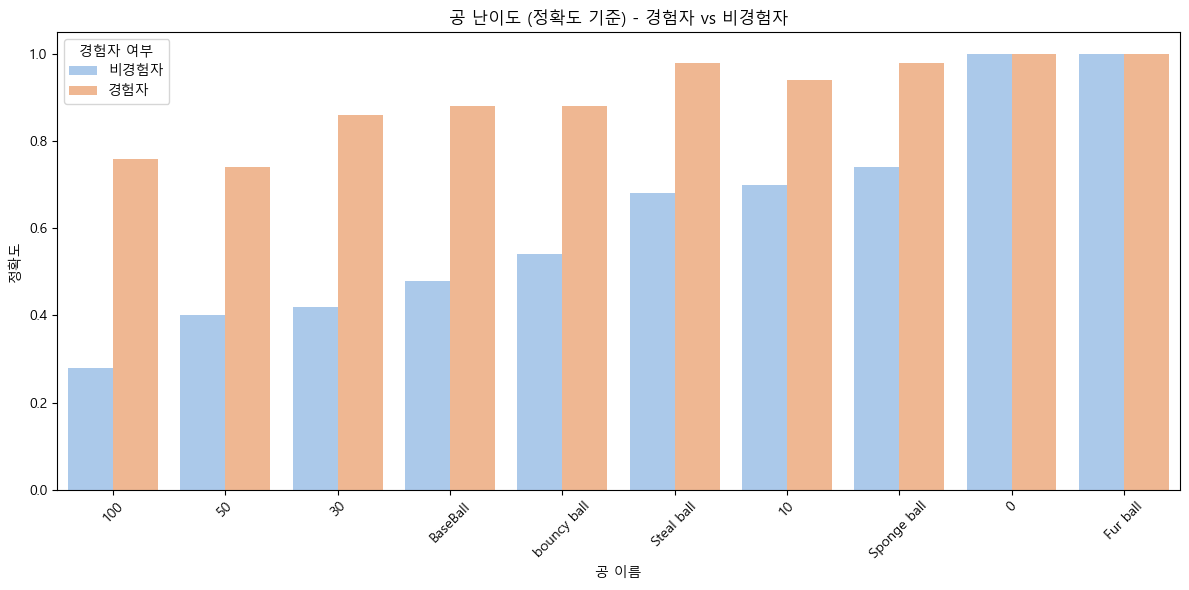

,object_name,경험자,비경험자
0,100,0.76,0.28
1,50,0.74,0.40
2,30,0.86,0.42
3,BaseBall,0.88,0.48
4,bouncy ball,0.88,0.54
5,Steal ball,0.98,0.68
6,10,0.94,0.70
7,Sponge ball,0.98,0.74
8,0,1.00,1.00
9,Fur ball,1.00,1.00


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 공별로 경험자/비경험자 구분된 정확도 계산
difficulty_by_exp = full_df.groupby(["object_name", "exp"]).agg(
    accuracy=("correct", "mean"),
    avg_grab=("object_grab", "mean"),
    avg_order=("order_in_session", "mean"),
    material=("material", "first")
).reset_index()

# 경험자 표시 텍스트로 변경
difficulty_by_exp["경험자구분"] = difficulty_by_exp["exp"].map({True: "경험자", False: "비경험자"})

# 정확도 기준 정렬 순서 (비경험자 기준으로 낮은 정확도부터)
order = (
    difficulty_by_exp[difficulty_by_exp["경험자구분"] == "비경험자"]
    .sort_values("accuracy")["object_name"]
    .tolist()
)
difficulty_by_exp["object_name"] = pd.Categorical(difficulty_by_exp["object_name"], categories=order, ordered=True)
difficulty_by_exp = difficulty_by_exp.sort_values("object_name")

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(
    data=difficulty_by_exp,
    x="object_name",
    y="accuracy",
    hue="경험자구분",
    palette="pastel"
)
plt.title("공 난이도 (정확도 기준) - 경험자 vs 비경험자")
plt.xlabel("공 이름")
plt.ylabel("정확도")
plt.xticks(rotation=45)
plt.legend(title="경험자 여부")
plt.tight_layout()
plt.show()

# 표 출력용 (피벗 형태로 보기 좋게)
difficulty_table = difficulty_by_exp.pivot(index="object_name", columns="경험자구분", values="accuracy").reset_index()
difficulty_table.columns.name = None

display(difficulty_table)


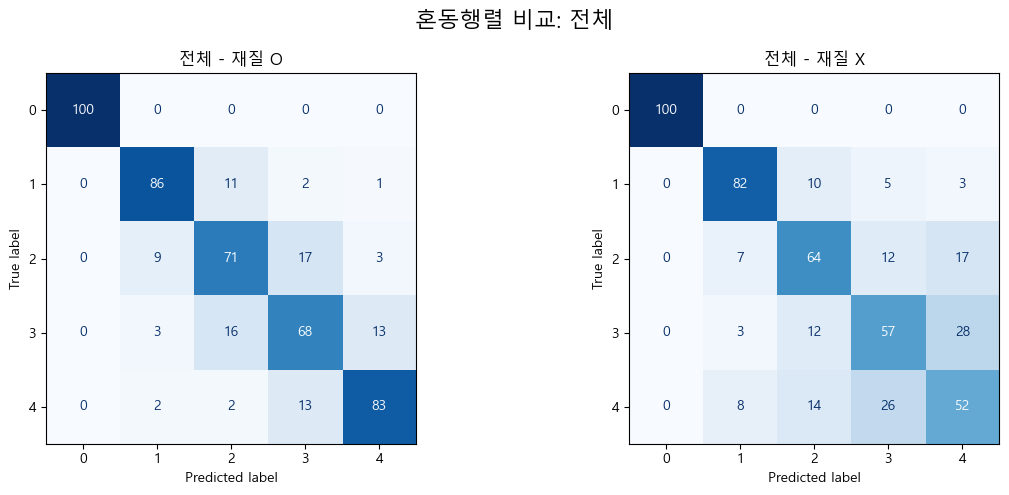

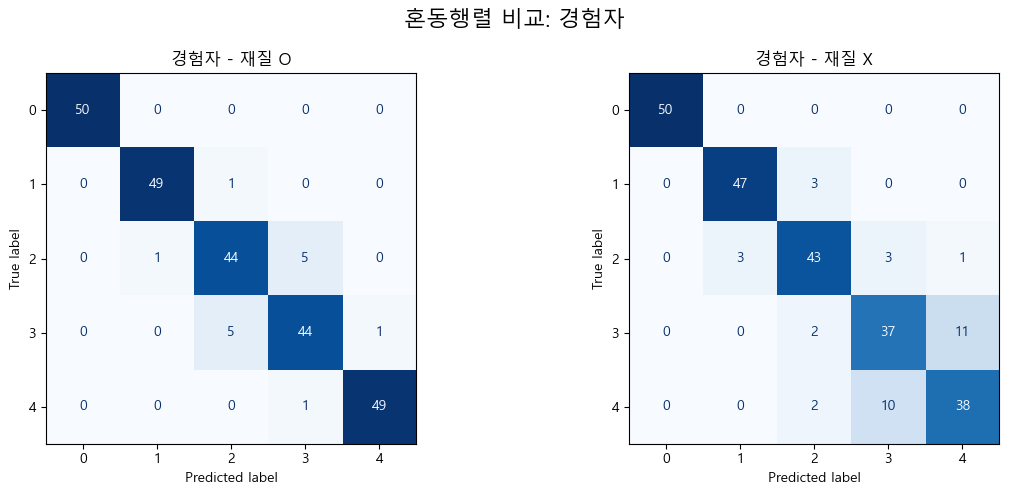

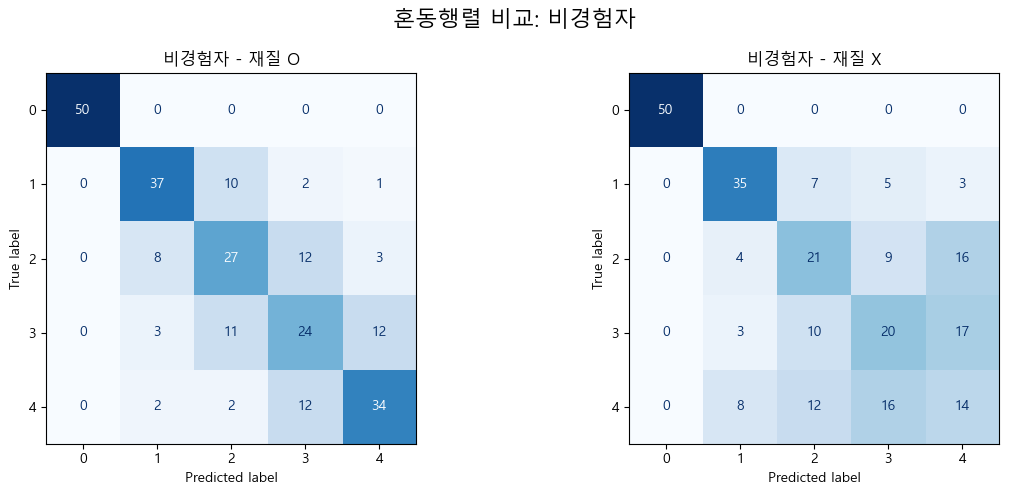

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 라벨 정의
labels = sorted(full_df["expected_zone"].unique())

# 3쌍으로 나눠서 구성: (title, dataframe)
group_pairs = [
    ("전체 - 재질 O", full_df[full_df["material"] == "재질 O"]),
    ("전체 - 재질 X", full_df[full_df["material"] == "재질 X"]),
    
    ("경험자 - 재질 O", full_df[(full_df["material"] == "재질 O") & (full_df["exp"] == True)]),
    ("경험자 - 재질 X", full_df[(full_df["material"] == "재질 X") & (full_df["exp"] == True)]),
    
    ("비경험자 - 재질 O", full_df[(full_df["material"] == "재질 O") & (full_df["exp"] == False)]),
    ("비경험자 - 재질 X", full_df[(full_df["material"] == "재질 X") & (full_df["exp"] == False)]),
]

# 2개씩 나누어 3개의 시각화 그룹 생성
for i in range(0, len(group_pairs), 2):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    pair = group_pairs[i:i+2]

    for ax, (title, df) in zip(axes, pair):
        cm = confusion_matrix(df["expected_zone"], df["zone"], labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(title)

    plt.suptitle("혼동행렬 비교: " + pair[0][0].split(" - ")[0], fontsize=16)
    plt.tight_layout()
    plt.show()


In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. zone 라벨 추출
labels = sorted(full_df["expected_zone"].unique())

# 2. 각 zone에 해당하는 공 이름 매핑 (첫 등장 기준)
zone_to_object = full_df.groupby("expected_zone")["object_name"].first().to_dict()

# 3. 전체 혼동행렬 계산
cm_all = confusion_matrix(full_df["expected_zone"], full_df["zone"], labels=labels)

# 4. 정확도 계산: 예측이 맞은 비율
accuracies = []
for idx, label in enumerate(labels):
    total = cm_all[idx].sum()
    correct = cm_all[idx, idx]
    acc = correct / total if total > 0 else np.nan
    accuracies.append({
        "zone": label,
        "공 이름": zone_to_object.get(label, f"Zone {label}"),
        "전체 시도 수": total,
        "정답 수": correct,
        "정확도": round(acc, 3)
    })

# 5. 표로 정리
accuracy_df = pd.DataFrame(accuracies).sort_values("정확도").reset_index(drop=True)
display(accuracy_df)


,zone,공 이름,전체 시도 수,정답 수,정확도
0,3,BaseBall,200,125,0.625
1,2,bouncy ball,200,135,0.675
2,4,Steal ball,200,135,0.675
3,1,Sponge ball,200,168,0.840
4,0,Fur ball,200,200,1.000


In [ ]:
from scipy.stats import spearmanr, pearsonr, shapiro
import pandas as pd

# 공별 요약 통계 생성
object_summary = full_df.groupby("object_name").agg(
    accuracy=("correct", "mean"),
    avg_grab=("object_grab", "mean"),
    avg_order=("order_in_session", "mean")
).reset_index()

# 분석 변수 쌍
var_pairs = [
    ("accuracy", "avg_grab"),
    ("accuracy", "avg_order")
]

# 결과 저장
correlation_results = []

for x, y in var_pairs:
    x_data = object_summary[x]
    y_data = object_summary[y]

    # 정규성 확인
    x_p = shapiro(x_data)[1]
    y_p = shapiro(y_data)[1]

    # 상관계수 계산
    if x_p > 0.05 and y_p > 0.05:
        corr, pval = pearsonr(x_data, y_data)
        method = "Pearson"
    else:
        corr, pval = spearmanr(x_data, y_data)
        method = "Spearman"

    correlation_results.append({
        "변수1": x,
        "변수2": y,
        "검정방법": method,
        "상관계수": round(corr, 3),
        "p-value": round(pval, 4)
    })

# 결과 출력
correlation_df = pd.DataFrame(correlation_results)
display(correlation_df)

,변수1,변수2,검정방법,상관계수,p-value
0,accuracy,avg_grab,Spearman,-0.839,0.0024
1,accuracy,avg_order,Pearson,-0.897,0.0004


In [22]:
import os
import pandas as pd
from glob import glob
from scipy.stats import ttest_ind, spearmanr, f_oneway

# 분석용 기준 세트
material_o = ["Fur ball", "Sponge ball", "bouncy ball", "BaseBall", "Steal ball"]
material_x = ["0", "10", "30", "50", "100"]
object_order = material_o + material_x

all_files = glob(os.path.join(output_dir, "*.csv"))

# 데이터 통합
all_data = []
for file in all_files:
    df = pd.read_csv(file)
    df["participant"] = os.path.basename(file).replace(".csv", "")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["session", "timestamp"])
    df["order_in_session"] = df.groupby("session").cumcount() + 1
    df["material"] = df["object_name"].apply(
        lambda x: "재질 O" if str(x) in material_o else ("재질 X" if str(x) in material_x else "Unknown")
    )
    all_data.append(df)

df_all = pd.concat(all_data, ignore_index=True)

# 공별 평균 등장 순서, grab, 정확도
grouped = df_all.groupby(["material", "object_name"]).agg(
    avg_order=("order_in_session", "mean"),
    avg_grab=("object_grab", "mean"),
    accuracy=("correct", "mean"),
    count=("object_name", "count")
).reset_index()

# 🔍 1. 재질 O vs X의 평균 등장 순서 비교 (독립표본 t-test)
material_o_order = df_all[df_all["material"] == "재질 O"]["order_in_session"]
material_x_order = df_all[df_all["material"] == "재질 X"]["order_in_session"]


# 🔍 분석 결과 테이블 출력
from IPython.display import display
grouped["object_name"] = pd.Categorical(grouped["object_name"], categories=object_order, ordered=True)
grouped = grouped.sort_values("object_name")
display(grouped)


,material,object_name,avg_order,avg_grab,accuracy,count
1,재질 O,Fur ball,1.67,1.63,1.00,100
2,재질 O,Sponge ball,2.76,3.40,0.86,100
4,재질 O,bouncy ball,3.69,4.63,0.71,100
0,재질 O,BaseBall,3.55,4.58,0.68,100
3,재질 O,Steal ball,3.33,4.21,0.83,100
5,재질 X,0,1.60,1.74,1.00,100
6,재질 X,10,2.65,3.57,0.82,100
8,재질 X,30,3.26,4.27,0.64,100
9,재질 X,50,3.88,5.00,0.57,100
7,재질 X,100,3.61,4.47,0.52,100


✅ 수행할 통계 검정 요약

<div class="pointer-events-none relative left-[50%]! flex w-[100cqw] translate-x-[-50%] justify-center *:pointer-events-auto"><div class="tableContainer horzScrollShadows"><table class="min-w-full" data-start="81" data-end="523"><thead data-start="81" data-end="146"><tr data-start="81" data-end="146"><th data-start="81" data-end="120"><strong data-start="83" data-end="92">검정 목적</strong></th><th data-start="120" data-end="146"><strong data-start="122" data-end="134">적용 통계 방법</strong></th></tr></thead><tbody data-start="223" data-end="523"><tr data-start="223" data-end="283"><td class="max-w-[calc(var(--thread-content-max-width)*2/3)]" data-start="223" data-end="255">재질 O vs X의 공별 평균 순서 비교</td><td class="max-w-[calc(var(--thread-content-max-width)*2/3)]" data-start="255" data-end="283">독립표본 t-test</td></tr><tr data-start="284" data-end="343"><td class="max-w-[calc(var(--thread-content-max-width)*2/3)]" data-start="284" data-end="315">재질 O vs X의 공별 평균 정확도 비교</td><td class="max-w-[calc(var(--thread-content-max-width)*2/3)]" data-start="315" data-end="343">독립표본 t-test</td></tr><tr data-start="344" data-end="404"><td class="max-w-[calc(var(--thread-content-max-width)*2/3)]" data-start="344" data-end="376">재질 O vs X의 공별 평균 grab 횟수 비교</td><td class="max-w-[calc(var(--thread-content-max-width)*2/3)]" data-start="376" data-end="404">독립표본 t-test</td></tr><tr data-start="405" data-end="462"><td class="max-w-[calc(var(--thread-content-max-width)*2/3)]" data-start="405" data-end="434">공별 정리 순서와 정확도의 관계</td><td class="max-w-[calc(var(--thread-content-max-width)*2/3)]" data-start="434" data-end="462">Spearman 상관분석</td></tr><tr data-start="463" data-end="523"><td class="max-w-[calc(var(--thread-content-max-width)*2/3)]" data-start="463" data-end="497">공별 정확도의 차이</td><td class="max-w-[calc(var(--thread-content-max-width)*2/3)]" data-start="497" data-end="523">일원분산분석 (ANOVA)</td></tr></tbody></table></div></div>

In [23]:
from scipy.stats import ttest_ind, spearmanr, f_oneway

# 재질별 데이터 분할
o_group = grouped[grouped["material"] == "재질 O"]
x_group = grouped[grouped["material"] == "재질 X"]

# ✅ 독립표본 t-test
t_order = ttest_ind(o_group["avg_order"], x_group["avg_order"], equal_var=False)
t_accuracy = ttest_ind(o_group["accuracy"], x_group["accuracy"], equal_var=False)
t_grab = ttest_ind(o_group["avg_grab"], x_group["avg_grab"], equal_var=False)

print("📌 재질 O vs X 평균 정확도 비교 (t-test)")
print(f"t = {t_accuracy.statistic:.4f}, p = {t_accuracy.pvalue:.4f}\n")

print("📌 재질 O vs X 평균 Grab 횟수 비교 (t-test)")
print(f"t = {t_grab.statistic:.4f}, p = {t_grab.pvalue:.4f}\n")

# ✅ 정리리 순서와 정확도 간의 상관관계
spearman_corr = spearmanr(grouped["avg_order"], grouped["accuracy"])
print("📌 공별 정리리 순서와 정확도 상관 (Spearman)")
print(f"Spearman correlation = {spearman_corr.correlation:.4f}, p = {spearman_corr.pvalue:.4f}\n")


📌 재질 O vs X 평균 정확도 비교 (t-test)
t = 1.0049, p = 0.3491

📌 재질 O vs X 평균 Grab 횟수 비교 (t-test)
t = -0.1507, p = 0.8839

📌 공별 정리리 순서와 정확도 상관 (Spearman)
Spearman correlation = -0.8024, p = 0.0052

